# 5주차 실습 (2) — Norms and Distances

> **당신이 고른 거리 함수가 "비슷하다"의 정의다. 잘못 고르면 그 아래 모든 것이 무너진다.**

- **Type:** Build · **Language:** Python · **Time:** ~90분
- **선수 지식:** Phase 1 Lesson 01(선형대수 직관), 02(벡터·행렬 연산)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/14-norms-and-distances>

## 🎯 학습 목표 (Learning Objectives)

1. **L1 · L2 · 코사인 · 마할라노비스 · 자카드 · 편집 거리**를 밑바닥부터 구현한다.
2. 주어진 ML 과제에 **맞는 거리 척도를 고르고**, 다른 후보가 왜 실패하는지 설명한다.
3. **L1 / L2 노름**을 LASSO · Ridge 정규화와 그 **기하학적 제약 영역**에 연결한다.
4. **같은 데이터가 척도에 따라 다른 최근접 이웃**을 내놓는 것을 직접 보인다.

---

## 📖 이 노트북을 읽는 법

> 🧸 **비유** (초등학생용) → 📐 **개념** (정확한 규칙) → 💻 **코드** (직접 증명) → 🏭 **실무** (어디에 쓰나)

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — "가까움"은 하나가 아니다 |
| 1 | 노름 = 벡터의 크기, 거리 = 차이의 크기 |
| 2 | L1(맨해튼) · L2(유클리드) · L∞(체비셰프) |
| 3 | Lp 노름 가족과 단위원의 모양 |
| 4 | 코사인 유사도 vs 내적 — 왜 NLP는 코사인인가 |
| 5 | 마할라노비스 거리 — 상관을 아는 거리 |
| 6 | 자카드(집합) · 편집 거리(문자열) |
| 7 | KL 발산 — 거리가 아닌데 거리처럼 쓰는 것 |
| 8 | Wasserstein 거리 — 겹치지 않아도 기울기를 준다 |
| 9 | 🔨 Build It — 같은 데이터, 다른 척도, 다른 이웃 |
| 10 | 🏭 Use It — 임베딩 검색 (코사인 vs L2) · ANN |
| 11 | 정규화와의 연결 — L1은 왜 0을 만들고 L2는 못 만드나 |
| 12 | 손실 함수와의 연결 (MSE · MAE · Huber) |
| 13 | 📝 연습문제 5개 (풀이 포함) |
| 14 | 📚 용어 사전 · 더 읽을거리 |

## 0️⃣ 문제 상황 (The Problem)

벡터 두 개가 있다. 워드 임베딩일 수도, 사용자 프로필일 수도, 픽셀 배열일 수도 있다.
알아야 할 건 하나다: **얼마나 가까운가?**

답은 **어떤 거리 함수를 고르느냐에 전적으로 달려 있다.**
같은 두 점이 어떤 척도에서는 최근접 이웃이고, 다른 척도에서는 한참 멀다.

```
KNN 분류기 · 추천 엔진 · 벡터 DB · 클러스터링 · 손실 함수
        ↑ 전부 이 선택 하나에 매달려 있다
```

**보편적으로 최고인 거리는 없다.**

| 데이터 | 지배적인 척도 |
| --- | --- |
| 공간 데이터 | L2 |
| 자연어 · 임베딩 | 코사인 |
| 집합 | 자카드 |
| 문자열 | 편집 거리 |
| 상관된 특징 | 마할라노비스 |
| 확률 분포 | KL · Wasserstein |

각각은 **"비슷하다"에 대한 서로 다른 가정**을 인코딩하고 있다.

---

### 🧭 잠깐 — 이 노트북의 지도

거리 함수는 결국 **"무엇을 무시할 것인가"** 의 선언이다.

```
L2       : 아무것도 무시하지 않음 (모든 축을 동등하게)
L1       : 큰 차이 하나가 지배하는 것을 무시
L∞       : 가장 큰 차이 빼고 전부 무시
코사인    : 길이(크기)를 무시  ← 그래서 문서 길이에 흔들리지 않는다
마할라노비스: 축의 스케일과 상관을 무시(=보정)
자카드    : 순서와 빈도를 무시
```

**당신의 과제에서 "무시해도 되는 것"이 무엇인지 정하면, 거리는 저절로 정해진다.**

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=4, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 로그축의 유니코드 마이너스(U+2212)가 깨지지 않는다.
        # 한글은 폴백 체인의 두 번째 폰트가 처리한다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [2]:
# 30초 데모 — 같은 두 문서 쌍인데 척도에 따라 정반대의 답이 나온다
doc_a = np.array([2.0, 1.0, 0.0])       # "고양이 고양이 강아지"
doc_b = np.array([20.0, 10.0, 0.0])     # 같은 주제인데 10배 긴 문서
doc_c = np.array([2.0, 0.0, 1.0])       # 다른 주제인데 길이는 비슷

l2 = lambda a, b: float(np.linalg.norm(a - b))
cos = lambda a, b: float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

print(f"{'쌍':<28}{'L2 거리':>12}{'코사인 유사도':>16}")
print("-" * 56)
print(f"{'A vs B (같은 주제, 긴 문서)':<24}{l2(doc_a, doc_b):>12.3f}{cos(doc_a, doc_b):>16.3f}")
print(f"{'A vs C (다른 주제, 같은 길이)':<23}{l2(doc_a, doc_c):>12.3f}{cos(doc_a, doc_c):>16.3f}")
print()
print("L2  판정: A는 C와 가깝다  (거리 1.41 < 20.1)  <- 문서 길이에 속았다")
print("코사인 판정: A는 B와 가깝다  (유사도 1.00 > 0.80)  <- 주제를 맞혔다")

쌍                                  L2 거리         코사인 유사도
--------------------------------------------------------
A vs B (같은 주제, 긴 문서)          20.125           1.000
A vs C (다른 주제, 같은 길이)         1.414           0.800

L2  판정: A는 C와 가깝다  (거리 1.41 < 20.1)  <- 문서 길이에 속았다
코사인 판정: A는 B와 가깝다  (유사도 1.00 > 0.80)  <- 주제를 맞혔다


## 1️⃣ 노름 = 벡터의 크기, 거리 = "차이의 크기"

### 📐 개념

**노름(norm)** 은 벡터의 "크기"를 재는 함수다. 그리고 **두 벡터 사이의 모든 거리는
차이 벡터의 노름으로 쓸 수 있다.**

$$d(a, b) = \lVert a - b \rVert$$

**→ 노름을 이해하면 거리를 이해한 것이다.** 노름이 되려면 세 조건을 만족해야 한다.

| 조건 | 의미 |
| --- | --- |
| `‖x‖ ≥ 0`, `‖x‖=0 ⟺ x=0` | 크기는 음수가 아니고, 0인 벡터만 크기가 0 |
| `‖cx‖ = |c|·‖x‖` | 벡터를 2배 늘리면 크기도 2배 (절대 동차성) |
| `‖x+y‖ ≤ ‖x‖ + ‖y‖` | 삼각 부등식 — 돌아가는 길이 더 짧을 수는 없다 |

> 💡 이 조건들을 어기면 "거리"라고 부를 수 없다. **KL 발산이 거리가 아닌 이유**가 여기 있다(7절).

## 2️⃣ L1(맨해튼) · L2(유클리드) · L∞(체비셰프)

### 🧸 비유 — 같은 두 지점, 세 가지 "거리"

집(1,1)에서 학교(4,5)까지.

- **L1(맨해튼)** = **택시로 간 거리.** 도로는 격자라 대각선으로 못 간다 → 동쪽 3블록 + 북쪽 4블록 = **7**
- **L2(유클리드)** = **드론으로 직선 비행.** √(3²+4²) = **5**
- **L∞(체비셰프)** = **체스의 킹.** 대각선도 한 칸이니 가장 큰 축 하나만 보면 된다 → max(3,4) = **4**

**항상 `L∞ ≤ L2 ≤ L1` 이다.** (연습문제 1번에서 증명)

### 📐 정의

$$\lVert x \rVert_1 = \sum_i |x_i| \qquad
\lVert x \rVert_2 = \sqrt{\sum_i x_i^2} \qquad
\lVert x \rVert_\infty = \max_i |x_i|$$

### 🏭 언제 쓰나

| 노름 | 쓰는 상황 | ML에서의 얼굴 |
| --- | --- | --- |
| **L1** | 고차원 희소 데이터, 이상치에 강해야 할 때, 특징 선택 | **MAE 손실**, **LASSO 정규화** |
| **L2** | 저·중차원 연속값, 스케일이 비슷할 때, 물리적 거리 | **MSE 손실**, **Ridge(weight decay)** |
| **L∞** | 단 하나의 축에서라도 최악 편차가 중요할 때 | 제조 공차, 적대적 공격의 ε-볼 |

- **L1이 이상치에 강한 이유**: 큰 차이 하나를 **선형으로만** 반영한다. L2는 제곱하므로 하나가 지배한다.
- **L1이 희소성을 만드는 이유**: 11절에서 그림으로 본다.

In [3]:
def l1_norm(x):
    return sum(abs(v) for v in x)

def l2_norm(x):
    return math.sqrt(sum(v * v for v in x))

def linf_norm(x):
    return max(abs(v) for v in x)

def lp_norm(x, p):
    if math.isinf(p):
        return linf_norm(x)
    return sum(abs(v) ** p for v in x) ** (1 / p)

diff = lambda a, b: [ai - bi for ai, bi in zip(a, b)]

A, B = [1.0, 1.0], [4.0, 5.0]
d = diff(A, B)
print(f"A={A}  B={B}   차이 벡터 = {d}")
print(f"  L1 (맨해튼)  = {l1_norm(d):.4f}   <- 격자 도로로 걸어간 거리")
print(f"  L2 (유클리드)= {l2_norm(d):.4f}   <- 직선 거리")
print(f"  L∞(체비셰프) = {linf_norm(d):.4f}   <- 가장 크게 벌어진 축 하나")
print(f"\n부등식 확인: L∞ {linf_norm(d):.3f} ≤ L2 {l2_norm(d):.3f} ≤ L1 {l1_norm(d):.3f}  "
      f"-> {linf_norm(d) <= l2_norm(d) <= l1_norm(d)}")

print("\n[이상치에 대한 반응 — L1이 강건한 이유]")
normal = [0.1, 0.1, 0.1, 0.1]
outlier = [0.1, 0.1, 0.1, 10.0]
print(f"{'오차 벡터':<28}{'L1':>10}{'L2':>10}{'L∞':>10}")
for name, v in [("정상 [0.1]*4", normal), ("이상치 하나 [.1,.1,.1,10]", outlier)]:
    print(f"{name:<28}{l1_norm(v):>10.3f}{l2_norm(v):>10.3f}{linf_norm(v):>10.3f}")
print("=> 이상치 하나로 L1은 26배, L2는 50배 커진다. L2가 이상치에 훨씬 민감하다.")

A=[1.0, 1.0]  B=[4.0, 5.0]   차이 벡터 = [-3.0, -4.0]
  L1 (맨해튼)  = 7.0000   <- 격자 도로로 걸어간 거리
  L2 (유클리드)= 5.0000   <- 직선 거리
  L∞(체비셰프) = 4.0000   <- 가장 크게 벌어진 축 하나

부등식 확인: L∞ 4.000 ≤ L2 5.000 ≤ L1 7.000  -> True

[이상치에 대한 반응 — L1이 강건한 이유]
오차 벡터                               L1        L2        L∞
정상 [0.1]*4                       0.400     0.200     0.100
이상치 하나 [.1,.1,.1,10]            10.300    10.001    10.000
=> 이상치 하나로 L1은 26배, L2는 50배 커진다. L2가 이상치에 훨씬 민감하다.


### 🖼️ 그림 1 — 같은 두 점, 세 개의 '거리'

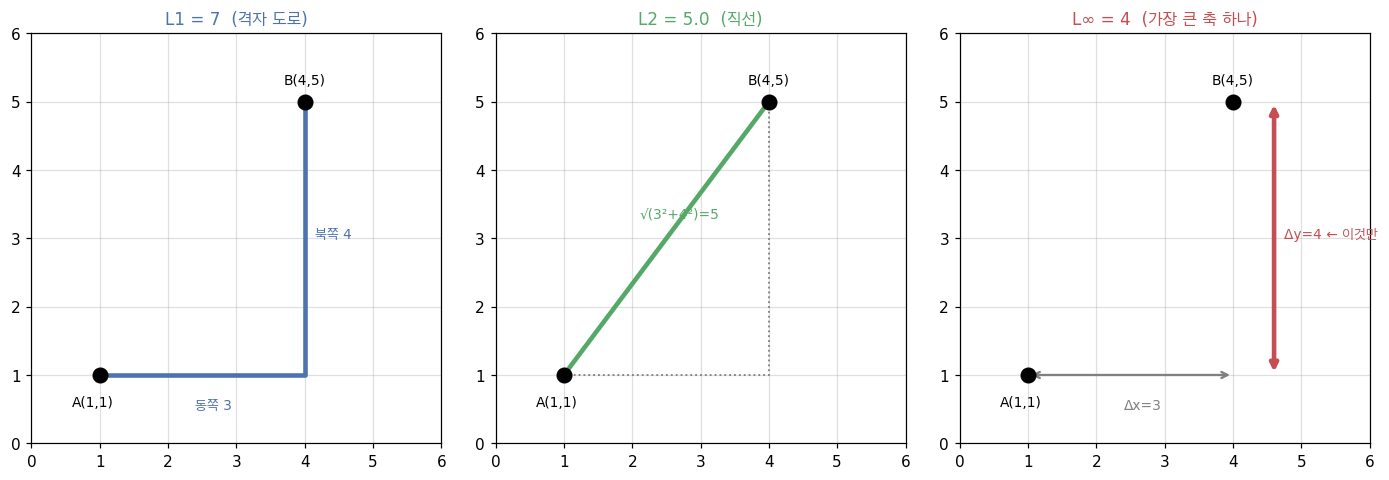

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
A, B = np.array([1, 1]), np.array([4, 5])

for ax, (title, color) in zip(axes, [("L1 = 7  (격자 도로)", "#4c72b0"),
                                     ("L2 = 5.0  (직선)", "#55a868"),
                                     ("L∞ = 4  (가장 큰 축 하나)", "#c44e52")]):
    ax.set_xticks(range(0, 7)); ax.set_yticks(range(0, 7))
    ax.grid(True, alpha=0.4)
    ax.set_xlim(0, 6); ax.set_ylim(0, 6); ax.set_aspect("equal")
    ax.scatter(*A, s=90, color="black", zorder=5)
    ax.scatter(*B, s=90, color="black", zorder=5)
    ax.text(A[0] - 0.1, A[1] - 0.45, "A(1,1)", fontsize=9, ha="center")
    ax.text(B[0], B[1] + 0.25, "B(4,5)", fontsize=9, ha="center")
    ax.set_title(title, fontsize=11, color=color)

# L1 : 계단 경로
axes[0].plot([1, 4, 4], [1, 1, 5], lw=3, color="#4c72b0", solid_capstyle="round")
axes[0].text(2.4, 0.5, "동쪽 3", color="#4c72b0", fontsize=9)
axes[0].text(4.15, 3, "북쪽 4", color="#4c72b0", fontsize=9)
# L2 : 직선
axes[1].plot([1, 4], [1, 5], lw=3, color="#55a868")
axes[1].plot([1, 4, 4], [1, 1, 5], lw=1.2, ls=":", color="gray")
axes[1].text(2.1, 3.3, "√(3²+4²)=5", color="#55a868", fontsize=9)
# Linf : 지배하는 축만
axes[2].annotate("", xy=(4, 1), xytext=(1, 1),
                 arrowprops=dict(arrowstyle="<->", color="gray", lw=1.5))
axes[2].annotate("", xy=(4.6, 5), xytext=(4.6, 1),
                 arrowprops=dict(arrowstyle="<->", color="#c44e52", lw=3))
axes[2].text(2.4, 0.5, "Δx=3", color="gray", fontsize=9)
axes[2].text(4.75, 3, "Δy=4 ← 이것만", color="#c44e52", fontsize=9)

plt.tight_layout()
plt.show()

## 3️⃣ Lp 노름 가족 — 단위원의 모양이 곧 그 노름의 성격이다

L1과 L2는 사실 하나의 가족이다.

$$\lVert x \rVert_p = \Big(\sum_i |x_i|^p\Big)^{1/p}$$

**단위 볼(unit ball)** = 원점에서 거리가 정확히 1인 점들의 집합. `p`에 따라 모양이 달라진다.

```
p = 1   : 다이아몬드(마름모)   ← 꼭짓점이 축 위에 있다
p = 2   : 원 / 구             ← 우리가 아는 그 동그라미
p = 3   : 모서리가 둥근 사각형
p = ∞   : 정사각형 / 초입방체  ← 변이 축과 평행
```

> 🔑 **11절의 복선:** L1 볼의 **꼭짓점이 축 위에 있다**는 사실이 곧 **LASSO가 가중치를 0으로 만드는 이유**다.

`p → ∞` 이면 왜 max가 되는가: 가장 큰 성분 `M`으로 묶어내면
`‖x‖_p = M·(1 + Σ(작은비율)^p)^(1/p)` 이고, `p`가 커지면 작은 비율의 `p`제곱이 0으로 사라진다.

In [5]:
x = [3.0, 4.0, 1.0]
print(f"x = {x}")
print(f"{'p':>6}{'‖x‖_p':>12}")
print("-" * 18)
for p in [1, 1.5, 2, 3, 5, 10, 50, 100]:
    print(f"{p:>6}{lp_norm(x, p):>12.6f}")
print(f"{'∞':>6}{linf_norm(x):>12.6f}   <- max(|3|,|4|,|1|)")
print("\n=> p가 커질수록 최댓값 4로 수렴한다. L∞가 'Lp의 극한'인 이유.")

x = [3.0, 4.0, 1.0]
     p       ‖x‖_p
------------------
     1    8.000000
   1.5    5.862917
     2    5.099020
     3    4.514357
     5    4.174686
    10    4.021975
    50    4.000000
   100    4.000000
     ∞    4.000000   <- max(|3|,|4|,|1|)

=> p가 커질수록 최댓값 4로 수렴한다. L∞가 'Lp의 극한'인 이유.


### 🖼️ 그림 2 — 단위 볼의 모양 (‖x‖_p = 1 인 점들)

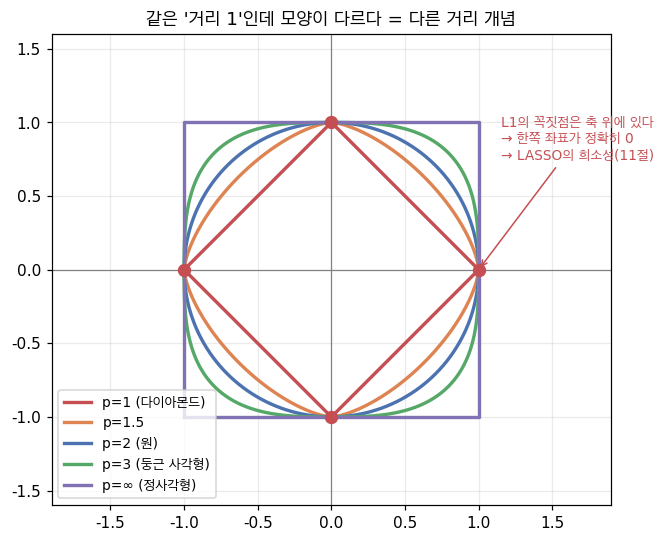

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
theta = np.linspace(0, 2 * np.pi, 1200)
palette = ["#c44e52", "#dd8452", "#4c72b0", "#55a868", "#8172b3"]

for (p, label), color in zip([(1, "p=1 (다이아몬드)"), (1.5, "p=1.5"), (2, "p=2 (원)"),
                              (3, "p=3 (둥근 사각형)")], palette):
    c, s = np.cos(theta), np.sin(theta)
    r = (np.abs(c) ** p + np.abs(s) ** p) ** (-1 / p)
    ax.plot(r * c, r * s, lw=2.2, color=color, label=label)

# p = inf : 정사각형
ax.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], lw=2.2, color=palette[4],
        label="p=∞ (정사각형)")

ax.scatter([1, -1, 0, 0], [0, 0, 1, -1], s=60, color="#c44e52", zorder=5)
ax.annotate("L1의 꼭짓점은 축 위에 있다\n→ 한쪽 좌표가 정확히 0\n→ LASSO의 희소성(11절)",
            xy=(1, 0), xytext=(1.15, 0.75), fontsize=9, color="#c44e52",
            arrowprops=dict(arrowstyle="->", color="#c44e52"))

ax.set_xlim(-1.9, 1.9); ax.set_ylim(-1.6, 1.6)
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.grid(alpha=0.25)
ax.legend(loc="lower left", fontsize=9)
ax.set_title("같은 '거리 1'인데 모양이 다르다 = 다른 거리 개념")
plt.tight_layout()
plt.show()

## 4️⃣ 코사인 유사도 vs 내적 — 왜 NLP는 코사인인가

### 🧸 비유 — 나침반과 줄자

- **L2 거리**는 줄자다. "너 나한테서 몇 미터 떨어져 있어?"
- **코사인 유사도**는 나침반이다. "너 나랑 **같은 방향** 보고 있어?"

고양이에 대한 문서 두 편이 있는데 하나는 10배 길다. 줄자로 재면 멀다. **나침반으로 재면 같은 방향이다.**
**문서 길이는 잡음이고, 방향이 의미**이기 때문에 NLP는 코사인을 쓴다.

### 📐 정의

$$\cos(a, b) = \frac{a \cdot b}{\lVert a \rVert_2 \, \lVert b \rVert_2}
\qquad d_{\cos}(a,b) = 1 - \cos(a,b)$$

- 범위: **−1(정반대) ~ +1(같은 방향)**, 수직이면 0
- 코사인 거리는 0(동일 방향) ~ 2(정반대)

### 📐 내적과의 관계

$$a \cdot b = \lVert a \rVert\,\lVert b \rVert \cos\theta$$

**두 벡터가 이미 단위 정규화(‖·‖=1)되어 있으면 내적 = 코사인 유사도다.**

| | 코사인 | 내적 |
| --- | --- | --- |
| 크기 정보 | 무시 | **반영** |
| 쓰는 곳 | 순수 방향 유사도, 문서 검색 | 크기가 인기·신뢰도를 뜻할 때(추천) |
| 벡터 DB | Pinecone/Weaviate/Qdrant 모두 선택 가능 | 임베딩이 L2 정규화되어 있으면 **둘은 같다** |

In [7]:
def dot(a, b):
    return sum(x * y for x, y in zip(a, b))

def cosine_similarity(a, b):
    na, nb = l2_norm(a), l2_norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return dot(a, b) / (na * nb)

def cosine_distance(a, b):
    return 1 - cosine_similarity(a, b)

a, b = [1.0, 0.0], [1.0, 1.0]
print(f"a={a}, b={b}")
print(f"  코사인 유사도 = {cosine_similarity(a, b):.6f}  (= 1/√2, 각도 45°)")
print(f"  코사인 거리   = {cosine_distance(a, b):.6f}")
print(f"  각도          = {math.degrees(math.acos(cosine_similarity(a, b))):.1f}°")

print("\n[내적 vs 코사인 — 크기를 반영하는가]")
a, b, c = [3.0, 0.0], [1.0, 0.0], [0.0, 1.0]
print(f"{'쌍':<12}{'내적':>10}{'코사인':>10}")
for name, (x, y) in [("a·b", (a, b)), ("a·c", (a, c)), ("b·c", (b, c))]:
    print(f"{name:<12}{dot(x, y):>10.3f}{cosine_similarity(x, y):>10.3f}")
print("=> 방향 판정은 같지만, 내적은 a가 3배 길다는 사실까지 점수에 넣는다.")

print("\n[L2 정규화하면 내적 == 코사인]")
unit = lambda v: [x / l2_norm(v) for x in v]
ua, ub = unit([3.0, 4.0]), unit([1.0, 2.0])
print(f"  정규화 후 내적   = {dot(ua, ub):.10f}")
print(f"  원본의 코사인    = {cosine_similarity([3.0, 4.0], [1.0, 2.0]):.10f}")

a=[1.0, 0.0], b=[1.0, 1.0]
  코사인 유사도 = 0.707107  (= 1/√2, 각도 45°)
  코사인 거리   = 0.292893
  각도          = 45.0°

[내적 vs 코사인 — 크기를 반영하는가]
쌍                   내적       코사인
a·b              3.000     1.000
a·c              0.000     0.000
b·c              0.000     0.000
=> 방향 판정은 같지만, 내적은 a가 3배 길다는 사실까지 점수에 넣는다.

[L2 정규화하면 내적 == 코사인]
  정규화 후 내적   = 0.9838699101
  원본의 코사인    = 0.9838699101


### 🖼️ 그림 3 — 길이를 무시한다는 것의 의미

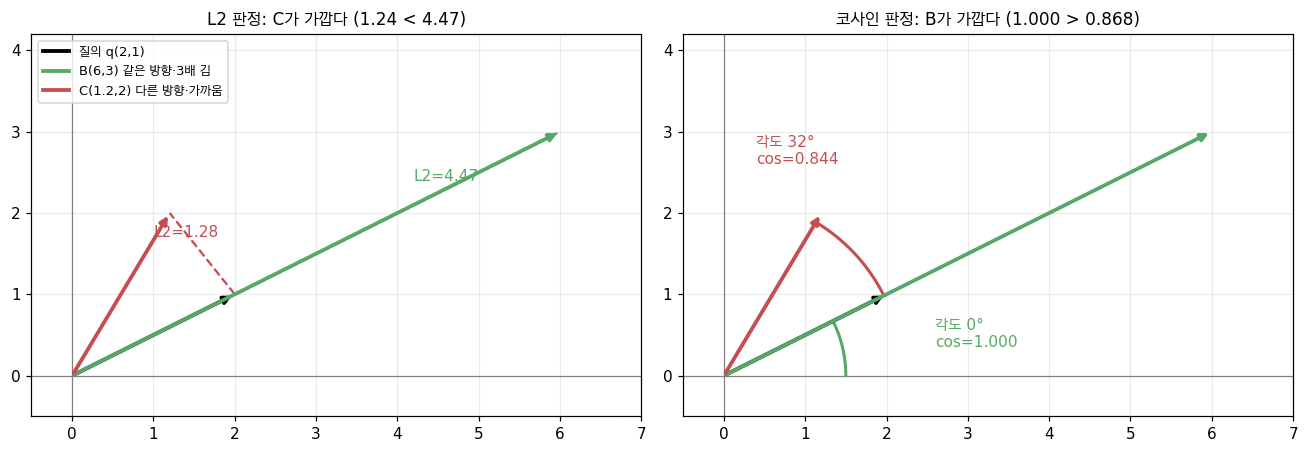

=> 같은 데이터, 정반대의 답. '길이를 무시할 것인가'가 유일한 차이다.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

q = np.array([2.0, 1.0])
same_dir_long = np.array([6.0, 3.0])     # 같은 방향, 3배 김
diff_dir_close = np.array([1.2, 2.0])    # 다른 방향, 가까움

for ax in (ax1, ax2):
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlim(-0.5, 7); ax.set_ylim(-0.5, 4.2); ax.set_aspect("equal"); ax.grid(alpha=0.25)
    for v, color, label in [(q, "black", "질의 q(2,1)"),
                            (same_dir_long, "#55a868", "B(6,3) 같은 방향·3배 김"),
                            (diff_dir_close, "#c44e52", "C(1.2,2) 다른 방향·가까움")]:
        ax.annotate("", xy=v, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", lw=2.5, color=color))
        ax.plot([], [], color=color, lw=2.5, label=label)

ax1.plot([q[0], same_dir_long[0]], [q[1], same_dir_long[1]], ls="--", color="#55a868")
ax1.plot([q[0], diff_dir_close[0]], [q[1], diff_dir_close[1]], ls="--", color="#c44e52")
ax1.text(4.2, 2.4, f"L2={np.linalg.norm(q-same_dir_long):.2f}", color="#55a868", fontsize=10)
ax1.text(1.0, 1.7, f"L2={np.linalg.norm(q-diff_dir_close):.2f}", color="#c44e52", fontsize=10)
ax1.set_title("L2 판정: C가 가깝다 (1.24 < 4.47)", fontsize=11)
ax1.legend(fontsize=8.5, loc="upper left")

arc = np.linspace(0, math.atan2(q[1], q[0]), 50)
ax2.plot(1.5 * np.cos(arc), 1.5 * np.sin(arc), color="#55a868", lw=2)
arc2 = np.linspace(math.atan2(q[1], q[0]), math.atan2(*diff_dir_close[::-1]), 50)
ax2.plot(2.2 * np.cos(arc2), 2.2 * np.sin(arc2), color="#c44e52", lw=2)
cb = cosine_similarity(list(q), list(same_dir_long))
cc = cosine_similarity(list(q), list(diff_dir_close))
ax2.text(2.6, 0.35, f"각도 0°\ncos={cb:.3f}", color="#55a868", fontsize=10)
ax2.text(0.4, 2.6, f"각도 {math.degrees(math.acos(cc)):.0f}°\ncos={cc:.3f}", color="#c44e52", fontsize=10)
ax2.set_title("코사인 판정: B가 가깝다 (1.000 > 0.868)", fontsize=11)

plt.tight_layout()
plt.show()
print("=> 같은 데이터, 정반대의 답. '길이를 무시할 것인가'가 유일한 차이다.")

## 5️⃣ 마할라노비스 거리 — 상관을 아는 거리

### 🧸 비유 — 키와 몸무게

- 키 188cm에 몸무게 82kg → **평범하다**
- 키 152cm에 몸무게 82kg → **드물다**

평균에서의 유클리드 거리는 **둘 다 같을 수 있다.** 하지만 우리는 두 번째가 이상하다는 걸 안다.
**키와 몸무게가 함께 움직인다(상관)** 는 걸 알기 때문이다.

마할라노비스 거리는 바로 그 지식을 거리에 넣은 것이다.

### 📐 정의

$$d_M(x, y) = \sqrt{(x-y)^\top S^{-1} (x-y)}$$

`S`는 데이터의 **공분산 행렬**이다. 직관적으로는:

```
1. 데이터를 화이트닝(whitening) = 상관 제거 + 각 축을 분산 1로 정규화
2. 그 공간에서 그냥 L2 거리를 잰다
```

`S = I`(무상관·단위분산)이면 **마할라노비스 = 유클리드**로 되돌아간다.

### 🏭 언제 쓰나

- **이상치 탐지** — 평균에서 마할라노비스 거리가 큰 점이 진짜 이상치
- 축마다 스케일·상관이 다른 분류 문제
- 신뢰할 만한 공분산을 추정할 만큼 데이터가 충분할 때
- 제조 품질 관리(다변량 공정 모니터링)

In [9]:
def mahalanobis(x, y, cov_inv):
    d = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    return float(math.sqrt(d @ cov_inv @ d))

rng = np.random.default_rng(3)
mean = np.array([170.0, 68.0])                      # 키(cm), 몸무게(kg)
cov = np.array([[100.0, 55.0], [55.0, 64.0]])       # 강한 양의 상관
data = rng.multivariate_normal(mean, cov, size=600)

S = np.cov(data.T)
S_inv = np.linalg.inv(S)
print("추정된 공분산 행렬 S =\n", S)
print(f"상관계수 = {S[0,1]/math.sqrt(S[0,0]*S[1,1]):.3f}")

p_normal = np.array([188.0, 82.0])     # 크고 무겁다 — 추세를 따름
p_weird = np.array([152.0, 82.0])      # 작은데 무겁다 — 추세를 거스름

print(f"\n{'점':<26}{'유클리드(평균까지)':>20}{'마할라노비스':>16}")
print("-" * 62)
for name, p in [("(188cm, 82kg) 추세대로", p_normal), ("(152cm, 82kg) 추세 역행", p_weird)]:
    print(f"{name:<26}{np.linalg.norm(p-mean):>20.3f}{mahalanobis(p, mean, S_inv):>16.3f}")

print("\n=> 유클리드는 두 점을 비슷하게 보지만, 마할라노비스는 두 번째를 명확한 이상치로 잡는다.")
print("   (마할라노비스 3 이상 = 흔히 쓰는 이상치 기준)")
print("\n참고: 그림의 '유클리드 등거리'는 실제로는 원이지만, 키(cm)와 몸무게(kg)의 축 스케일이")
print("      달라 화면에서는 눌린 타원처럼 보인다.")
print(f"\n검증: S = I 이면 마할라노비스 == 유클리드 -> "
      f"{mahalanobis(p_weird, mean, np.eye(2)):.4f} vs {np.linalg.norm(p_weird-mean):.4f}")

추정된 공분산 행렬 S =
 [[100.5899  52.4437]
 [ 52.4437  60.2463]]
상관계수 = 0.674

점                                   유클리드(평균까지)          마할라노비스
--------------------------------------------------------------
(188cm, 82kg) 추세대로                      22.804           1.967
(152cm, 82kg) 추세 역행                     22.804           4.454

=> 유클리드는 두 점을 비슷하게 보지만, 마할라노비스는 두 번째를 명확한 이상치로 잡는다.
   (마할라노비스 3 이상 = 흔히 쓰는 이상치 기준)

참고: 그림의 '유클리드 등거리'는 실제로는 원이지만, 키(cm)와 몸무게(kg)의 축 스케일이
      달라 화면에서는 눌린 타원처럼 보인다.

검증: S = I 이면 마할라노비스 == 유클리드 -> 22.8035 vs 22.8035


### 🖼️ 그림 4 — 원(유클리드) vs 타원(마할라노비스)

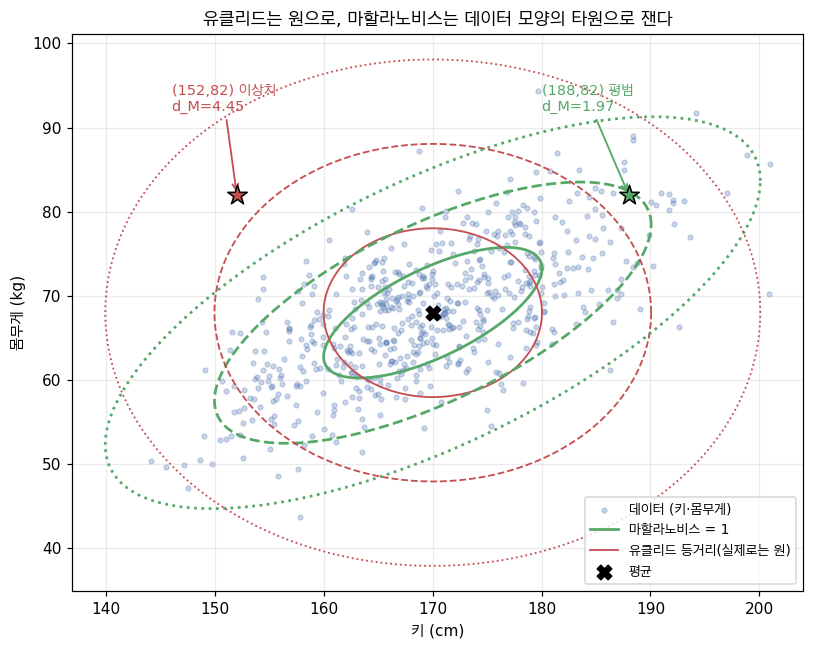

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(data[:, 0], data[:, 1], s=10, alpha=0.28, color="#4c72b0", label="데이터 (키·몸무게)")

theta = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(theta), np.sin(theta)])
L = np.linalg.cholesky(S)
for k, ls in [(1, "-"), (2, "--"), (3, ":")]:
    e = mean[:, None] + k * (L @ circle)
    ax.plot(e[0], e[1], color="#55a868", ls=ls, lw=1.8,
            label=f"마할라노비스 = {k}" if k == 1 else None)
    c = mean[:, None] + k * math.sqrt(S[0, 0]) * circle
    ax.plot(c[0], c[1], color="#c44e52", ls=ls, lw=1.2,
            label="유클리드 등거리(실제로는 원)" if k == 1 else None)

for p, name, color, tx in [(p_normal, "(188,82) 평범", "#55a868", (180, 92)),
                           (p_weird, "(152,82) 이상치", "#c44e52", (146, 92))]:
    ax.scatter(*p, s=180, marker="*", color=color, edgecolor="black", zorder=6)
    ax.annotate(f"{name}\nd_M={mahalanobis(p, mean, S_inv):.2f}", xy=p, xytext=tx,
                fontsize=9.5, color=color,
                arrowprops=dict(arrowstyle="->", color=color, lw=1.2))
ax.scatter(*mean, s=90, marker="X", color="black", zorder=6, label="평균")

ax.set_xlabel("키 (cm)"); ax.set_ylabel("몸무게 (kg)")
ax.set_title("유클리드는 원으로, 마할라노비스는 데이터 모양의 타원으로 잰다")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6️⃣ 자카드(집합) · 편집 거리(문자열)

여기까지는 전부 **벡터**의 거리였다. 하지만 데이터가 언제나 벡터인 건 아니다.

### 📐 자카드 유사도 — 집합의 겹침

$$J(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

```
A = {고양이, 개, 물고기}
B = {고양이, 새, 물고기, 뱀}

교집합 = {고양이, 물고기}                    크기 2
합집합 = {고양이, 개, 물고기, 새, 뱀}         크기 5
자카드 유사도 = 2/5 = 0.4,   자카드 거리 = 0.6
```

**🏭 어디에 쓰나:** 태그·카테고리 비교, **단어 등장 여부**(빈도 무시) 기반 문서 유사도,
중복 문서 탐지(MinHash), 이진 특징 벡터, **분할 모델 평가(IoU = 자카드)**

### 📐 편집 거리 (Levenshtein) — 문자열

한 문자열을 다른 문자열로 바꾸는 **최소 편집 횟수**(삽입·삭제·치환).

```
kitten → sitten  (k를 s로 치환)
sitten → sittin  (e를 i로 치환)
sittin → sitting (g 삽입)
                     편집 거리 = 3
```

**동적 계획법**으로 계산한다. `(i,j)` 칸 = A의 앞 `i`글자와 B의 앞 `j`글자 사이의 편집 거리.

**🏭 어디에 쓰나:** 맞춤법 교정, DNA 서열 정렬(연산별 가중치 부여), 퍼지 문자열 매칭, 지저분한 텍스트 중복 제거

In [11]:
def jaccard_similarity(a, b):
    a, b = set(a), set(b)
    union = a | b
    if not union:
        return 1.0
    return len(a & b) / len(union)

def jaccard_distance(a, b):
    return 1 - jaccard_similarity(a, b)

A = {"고양이", "개", "물고기"}
B = {"고양이", "새", "물고기", "뱀"}
print(f"A = {A}")
print(f"B = {B}")
print(f"  교집합 {sorted(A & B)}  크기 {len(A & B)}")
print(f"  합집합 {sorted(A | B)}  크기 {len(A | B)}")
print(f"  자카드 유사도 = {jaccard_similarity(A, B):.4f}")
print(f"  자카드 거리   = {jaccard_distance(A, B):.4f}")

print("\n[🏭 IoU는 자카드와 같은 것이다 — 분할/검출 모델 평가지표]")
# 두 박스를 픽셀 집합으로 보고 IoU 계산
box_pred = {(x, y) for x in range(2, 8) for y in range(2, 8)}    # 6x6 예측
box_true = {(x, y) for x in range(3, 9) for y in range(3, 9)}    # 6x6 정답 (한 칸씩 어긋남)
print(f"  예측 박스 픽셀 {len(box_pred)}개, 정답 박스 픽셀 {len(box_true)}개")
print(f"  IoU = {jaccard_similarity(box_pred, box_true):.4f}   (= 자카드 유사도)")
print(f"  통상 IoU ≥ 0.5 를 '검출 성공'으로 본다 -> "
      f"{'성공' if jaccard_similarity(box_pred, box_true) >= 0.5 else '실패'}")

A = {'물고기', '개', '고양이'}
B = {'물고기', '뱀', '고양이', '새'}
  교집합 ['고양이', '물고기']  크기 2
  합집합 ['개', '고양이', '물고기', '뱀', '새']  크기 5
  자카드 유사도 = 0.4000
  자카드 거리   = 0.6000

[🏭 IoU는 자카드와 같은 것이다 — 분할/검출 모델 평가지표]
  예측 박스 픽셀 36개, 정답 박스 픽셀 36개
  IoU = 0.5319   (= 자카드 유사도)
  통상 IoU ≥ 0.5 를 '검출 성공'으로 본다 -> 성공


In [12]:
def edit_distance(a, b, return_table=False):
    n, m = len(a), len(b)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i                      # a의 i글자를 전부 삭제
    for j in range(m + 1):
        dp[0][j] = j                      # b의 j글자를 전부 삽입
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1,        # 삭제
                           dp[i][j - 1] + 1,        # 삽입
                           dp[i - 1][j - 1] + cost)  # 치환(같으면 공짜)
    return (dp[n][m], dp) if return_table else dp[n][m]

dist, table = edit_distance("kitten", "sitting", return_table=True)
print(f'편집 거리("kitten", "sitting") = {dist}\n')

header = "        " + "".join(f"{ch:>4}" for ch in ' ' + "sitting")
print(header)
for i, row in enumerate(table):
    label = " " if i == 0 else "kitten"[i - 1]
    print(f"{label:>6}  " + "".join(f"{v:>4}" for v in row))

print("\n[다른 예시]")
for a, b in [("kitten", "sitting"), ("flaw", "lawn"), ("cat", "cat"),
             ("intention", "execution"), ("서울", "서울시")]:
    print(f'  edit("{a}", "{b}") = {edit_distance(a, b)}')

편집 거리("kitten", "sitting") = 3

               s   i   t   t   i   n   g
           0   1   2   3   4   5   6   7
     k     1   1   2   3   4   5   6   7
     i     2   2   1   2   3   4   5   6
     t     3   3   2   1   2   3   4   5
     t     4   4   3   2   1   2   3   4
     e     5   5   4   3   2   2   3   4
     n     6   6   5   4   3   3   2   3

[다른 예시]
  edit("kitten", "sitting") = 3
  edit("flaw", "lawn") = 2
  edit("cat", "cat") = 0
  edit("intention", "execution") = 5
  edit("서울", "서울시") = 1


### 🖼️ 그림 5 — 편집 거리 DP 표와 최적 경로

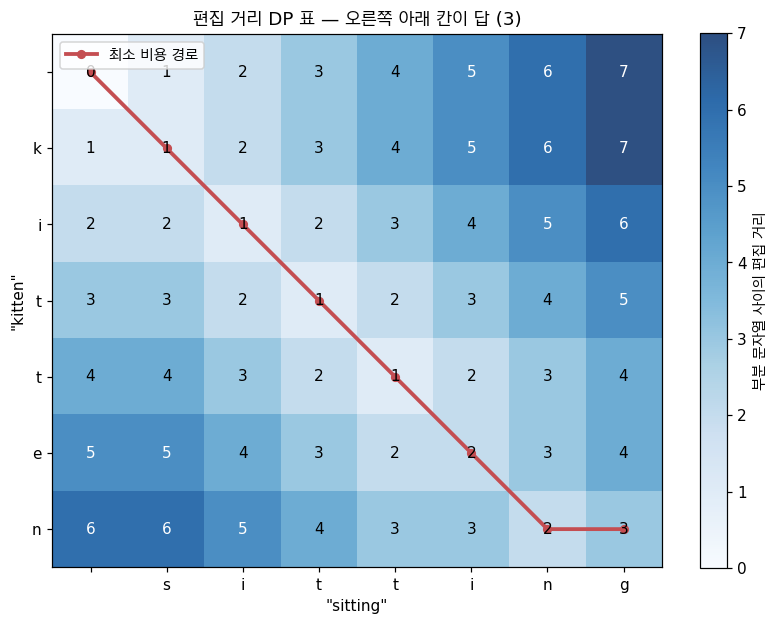

In [13]:
a, b = "kitten", "sitting"
_, table = edit_distance(a, b, return_table=True)
T = np.array(table)

# 역추적: 오른쪽 아래에서 왼쪽 위로 최소 비용 경로를 따라간다
path = [(len(a), len(b))]
i, j = len(a), len(b)
while (i, j) != (0, 0):
    cands = []
    if i > 0 and j > 0:
        cands.append((T[i-1][j-1] + (0 if a[i-1] == b[j-1] else 1), i-1, j-1))
    if i > 0:
        cands.append((T[i-1][j] + 1, i-1, j))
    if j > 0:
        cands.append((T[i][j-1] + 1, i, j-1))
    _, i, j = min(cands, key=lambda c: (c[0] != T[path[-1][0]][path[-1][1]], c[0]))
    path.append((i, j))

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(T, cmap="Blues", alpha=0.85)
for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        ax.text(j, i, T[i, j], ha="center", va="center", fontsize=10,
                color="white" if T[i, j] > 4 else "black")
py, px = zip(*path)
ax.plot(px, py, color="#c44e52", lw=2.5, marker="o", ms=5, label="최소 비용 경로")
ax.set_xticks(range(len(b) + 1)); ax.set_xticklabels([""] + list(b))
ax.set_yticks(range(len(a) + 1)); ax.set_yticklabels([""] + list(a))
ax.set_xlabel('"sitting"'); ax.set_ylabel('"kitten"')
ax.set_title(f'편집 거리 DP 표 — 오른쪽 아래 칸이 답 ({T[-1,-1]})')
ax.legend(loc="upper left")
plt.colorbar(im, ax=ax, shrink=0.8, label="부분 문자열 사이의 편집 거리")
plt.tight_layout()
plt.show()

## 7️⃣ KL 발산 — 거리가 아닌데 거리처럼 쓰는 것

3주차에서 다뤘지만, **"거리"라고 부르면서 거리가 아닌 대표 사례**이므로 여기서 다시 본다.

$$D_{KL}(P \Vert Q) = \sum_x p(x)\log\frac{p(x)}{q(x)}$$

### ⚠️ 왜 거리가 아닌가

$$D_{KL}(P \Vert Q) \neq D_{KL}(Q \Vert P)$$

**대칭성이 깨진다.** 삼각 부등식도 성립하지 않는다. 그래서 **거리(distance)가 아니라 발산(divergence)** 이다.

### 📐 방향이 만드는 성격 차이

| | Forward KL `D(P‖Q)` | Reverse KL `D(Q‖P)` |
| --- | --- | --- |
| 성격 | **mean-seeking** (평균 추구) | **mode-seeking** (봉우리 추구) |
| 행동 | Q가 P의 **모든 봉우리를 덮으려** 한다 | Q가 **하나의 봉우리에 집중**한다 |
| 이유 | `p>0`인데 `q≈0`이면 벌점이 무한 | `q>0`인데 `p≈0`이면 벌점이 무한 |
| 등장 | 최대우도, 지도학습 | 변분추론, VAE, RL 정책 |

### 🏭 KL을 만나는 곳

- **VAE** — ELBO의 KL 항이 잠재분포를 사전분포 쪽으로 민다
- **지식 증류** — 학생이 교사의 분포를 따라간다
- **RLHF** — KL 페널티가 파인튜닝 모델을 베이스 모델 근처에 붙잡아 둔다
- **정책 경사법** — 정책 업데이트 폭을 제한

In [14]:
def kl_divergence(p, q, eps=1e-12):
    # 주의: q=0 을 eps로 클램프하므로 수학적 ∞ 가 log(1/eps)≈27.6 이라는 큰 유한값으로 나온다
    p = np.asarray(p, dtype=float); q = np.asarray(q, dtype=float)
    mask = p > 0
    return float(np.sum(p[mask] * np.log(p[mask] / np.maximum(q[mask], eps))))

P = [0.7, 0.2, 0.1]
Q = [0.4, 0.4, 0.2]
print(f"P = {P}\nQ = {Q}")
print(f"  D_KL(P‖Q) = {kl_divergence(P, Q):.6f}")
print(f"  D_KL(Q‖P) = {kl_divergence(Q, P):.6f}")
print(f"  대칭인가? {math.isclose(kl_divergence(P,Q), kl_divergence(Q,P))}  <- 거리가 아니다")

print("\n[삼각 부등식도 깨진다]")
R = [0.1, 0.1, 0.8]
pq, qr, pr = kl_divergence(P, Q), kl_divergence(Q, R), kl_divergence(P, R)
print(f"  D(P‖Q)={pq:.4f}  D(Q‖R)={qr:.4f}  합={pq+qr:.4f}   vs   D(P‖R)={pr:.4f}")
print(f"  D(P‖R) ≤ D(P‖Q)+D(Q‖R) ? {pr <= pq + qr}  <- 실제로 위반됐다. 삼각 부등식이 성립하지 않는다")

print("\n[겹치지 않는 분포에서는 무한대로 발산]")
P2 = [1.0, 0.0, 0.0, 0.0, 0.0]
Q2 = [0.0, 0.0, 0.0, 0.0, 1.0]
print(f"  P={P2}\n  Q={Q2}")
print(f"  D_KL(P‖Q) = {kl_divergence(P2, Q2):.1f}   <- 수학적으로는 ∞ (log(1/0)).")
print(f"     위 값은 q=0을 ε=1e-12로 클램프해서 나온 log(1/ε)={math.log(1e12):.1f} 이다.")
print("     중요한 건 값이 아니라 '겹치지 않으면 기울기가 없다'는 사실.")
print("  => 8절 Wasserstein이 필요한 이유가 정확히 이것이다.")

P = [0.7, 0.2, 0.1]
Q = [0.4, 0.4, 0.2]
  D_KL(P‖Q) = 0.183787
  D_KL(Q‖P) = 0.192042
  대칭인가? False  <- 거리가 아니다

[삼각 부등식도 깨진다]
  D(P‖Q)=0.1838  D(Q‖R)=0.8318  합=1.0156   vs   D(P‖R)=1.2928
  D(P‖R) ≤ D(P‖Q)+D(Q‖R) ? False  <- 실제로 위반됐다. 삼각 부등식이 성립하지 않는다

[겹치지 않는 분포에서는 무한대로 발산]
  P=[1.0, 0.0, 0.0, 0.0, 0.0]
  Q=[0.0, 0.0, 0.0, 0.0, 1.0]
  D_KL(P‖Q) = 27.6   <- 수학적으로는 ∞ (log(1/0)).
     위 값은 q=0을 ε=1e-12로 클램프해서 나온 log(1/ε)=27.6 이다.
     중요한 건 값이 아니라 '겹치지 않으면 기울기가 없다'는 사실.
  => 8절 Wasserstein이 필요한 이유가 정확히 이것이다.


### 🖼️ 그림 6 — Forward KL(평균 추구) vs Reverse KL(봉우리 추구)

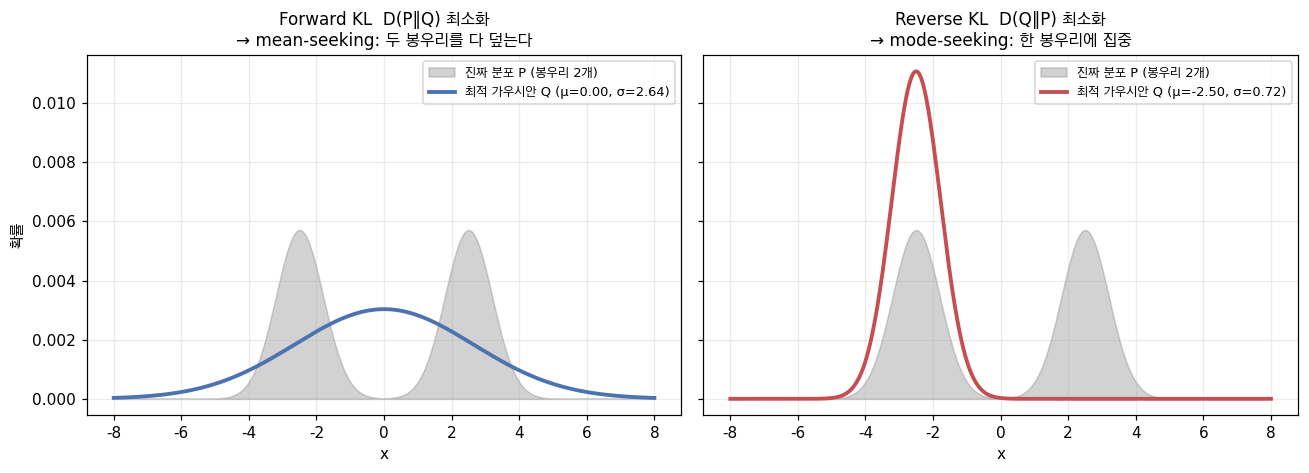

Forward KL 최적: μ=0.00, σ=2.64  (KL=0.6159)
Reverse KL 최적: μ=-2.50, σ=0.72  (KL=0.6933)

같은 P, 같은 후보군인데 방향만 바꿨더니 완전히 다른 답이 나온다.
=> KL은 방향을 가진다. '거리'라는 단어를 쓰면 이 사실을 잊게 된다.


In [15]:
xs = np.linspace(-8, 8, 800)
gauss = lambda x, mu, s: np.exp(-0.5 * ((x - mu) / s) ** 2) / (s * math.sqrt(2 * math.pi))
p = 0.5 * gauss(xs, -2.5, 0.7) + 0.5 * gauss(xs, 2.5, 0.7)   # 봉우리 두 개
p = p / p.sum()

mus = np.linspace(-5, 5, 101)
sigmas = np.linspace(0.3, 4.0, 80)

def fit(objective):
    best, best_val = None, float("inf")
    for mu in mus:
        for s in sigmas:
            q = gauss(xs, mu, s); q = q / q.sum()
            val = objective(p, q)
            if val < best_val:
                best_val, best = val, (mu, s)
    return best, best_val

(fw_mu, fw_s), fw_val = fit(lambda p, q: kl_divergence(p, q))   # forward  D(P‖Q)
(rv_mu, rv_s), rv_val = fit(lambda p, q: kl_divergence(q, p))   # reverse  D(Q‖P)

q_fw = gauss(xs, fw_mu, fw_s); q_fw /= q_fw.sum()
q_rv = gauss(xs, rv_mu, rv_s); q_rv /= q_rv.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, q, title, color, (mu, s), val in [
    (ax1, q_fw, "Forward KL  D(P‖Q) 최소화\n→ mean-seeking: 두 봉우리를 다 덮는다", "#4c72b0", (fw_mu, fw_s), fw_val),
    (ax2, q_rv, "Reverse KL  D(Q‖P) 최소화\n→ mode-seeking: 한 봉우리에 집중", "#c44e52", (rv_mu, rv_s), rv_val),
]:
    ax.fill_between(xs, p, color="gray", alpha=0.35, label="진짜 분포 P (봉우리 2개)")
    ax.plot(xs, q, lw=2.5, color=color, label=f"최적 가우시안 Q (μ={mu:.2f}, σ={s:.2f})")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8.5)
    ax.set_xlabel("x")
    ax.grid(alpha=0.25)
ax1.set_ylabel("확률")
plt.tight_layout()
plt.show()

print(f"Forward KL 최적: μ={fw_mu:.2f}, σ={fw_s:.2f}  (KL={fw_val:.4f})")
print(f"Reverse KL 최적: μ={rv_mu:.2f}, σ={rv_s:.2f}  (KL={rv_val:.4f})")
print("\n같은 P, 같은 후보군인데 방향만 바꿨더니 완전히 다른 답이 나온다.")
print("=> KL은 방향을 가진다. '거리'라는 단어를 쓰면 이 사실을 잊게 된다.")

## 8️⃣ Wasserstein 거리 (Earth Mover's Distance)

### 🧸 비유 — 흙더미 옮기기

한 분포는 **흙더미**, 다른 분포는 **구덩이**다.
**"흙을 얼마나, 얼마나 멀리 옮겨야 하는가"** 가 Wasserstein 거리다.

### 📐 정의

$$W(P,Q) = \inf_{\gamma \in \Gamma(P,Q)} \mathbb{E}_{(x,y)\sim\gamma}\big[d(x,y)\big]$$

1차원에서는 **누적분포함수(CDF) 차이의 적분**으로 아주 간단해진다.

$$W_1(P,Q) = \int \big|\,F_P(x) - F_Q(x)\,\big|\,dx$$

### 🔑 왜 중요한가

- **진짜 거리다** — 대칭이고 삼각 부등식을 만족한다 (KL과 달리)
- **두 분포가 겹치지 않아도 유의미한 기울기를 준다** — KL은 이때 무한대로 터진다

```
P: [1, 0, 0, 0, 0]      Q: [0, 0, 0, 0, 1]

KL 발산     : 무한대 (log(1/0))  -> 학습 신호 없음
Wasserstein : 4      (질량을 4칸 옮김) -> 기울기 있음
```

**이 성질이 WGAN이 원조 GAN의 학습 불안정을 해결한 핵심**이다.

### 🏭 어디에 쓰나

GAN 학습(WGAN, WGAN-GP) · 겹치지 않을 수 있는 분포 비교 · 최적 수송 문제 · 색 히스토그램 기반 이미지 검색

In [16]:
def wasserstein_1d(p, q, positions=None):
    # 1D CDF 방법: W1 = Σ |CDF_P - CDF_Q| × (칸 사이 간격)
    p = np.asarray(p, dtype=float); q = np.asarray(q, dtype=float)
    p, q = p / p.sum(), q / q.sum()
    if positions is None:
        positions = np.arange(len(p), dtype=float)
    widths = np.diff(positions)
    cdf_diff = np.abs(np.cumsum(p) - np.cumsum(q))[:-1]
    return float(np.sum(cdf_diff * widths))

P = [1.0, 0.0, 0.0, 0.0, 0.0]
Q = [0.0, 0.0, 0.0, 0.0, 1.0]
print("겹치지 않는 두 분포")
print(f"  P = {P}\n  Q = {Q}")
print(f"  KL 발산     = {kl_divergence(P, Q):.1f}   <- 기울기 없음")
print(f"  Wasserstein = {wasserstein_1d(P, Q):.1f}     <- 질량을 4칸 옮긴 비용")

print("\n[Q를 조금씩 P 쪽으로 옮겨 보면]")
print(f"{'Q의 위치':>10}{'KL':>14}{'Wasserstein':>16}")
print("-" * 42)
for pos in range(5):
    Qk = [0.0] * 5
    Qk[pos] = 1.0
    kl = kl_divergence(P, Qk)
    print(f"{pos:>10}{('inf' if math.isinf(kl) else f'{kl:.2f}'):>14}"
          f"{wasserstein_1d(P, Qk):>16.2f}")
print("=> KL은 겹치기 전까지 계속 같은 값(수학적으로는 ∞)이라 '가까워지고 있다'를 알려주지 못한다.")
print("   Wasserstein은 4,3,2,1,0으로 매끄럽게 줄어든다 = 학습에 쓸 기울기가 있다.")

겹치지 않는 두 분포
  P = [1.0, 0.0, 0.0, 0.0, 0.0]
  Q = [0.0, 0.0, 0.0, 0.0, 1.0]
  KL 발산     = 27.6   <- 기울기 없음
  Wasserstein = 4.0     <- 질량을 4칸 옮긴 비용

[Q를 조금씩 P 쪽으로 옮겨 보면]
     Q의 위치            KL     Wasserstein
------------------------------------------
         0          0.00            0.00
         1         27.63            1.00
         2         27.63            2.00
         3         27.63            3.00
         4         27.63            4.00
=> KL은 겹치기 전까지 계속 같은 값(수학적으로는 ∞)이라 '가까워지고 있다'를 알려주지 못한다.
   Wasserstein은 4,3,2,1,0으로 매끄럽게 줄어든다 = 학습에 쓸 기울기가 있다.


### 🖼️ 그림 7 — CDF 사이의 면적이 곧 Wasserstein 거리

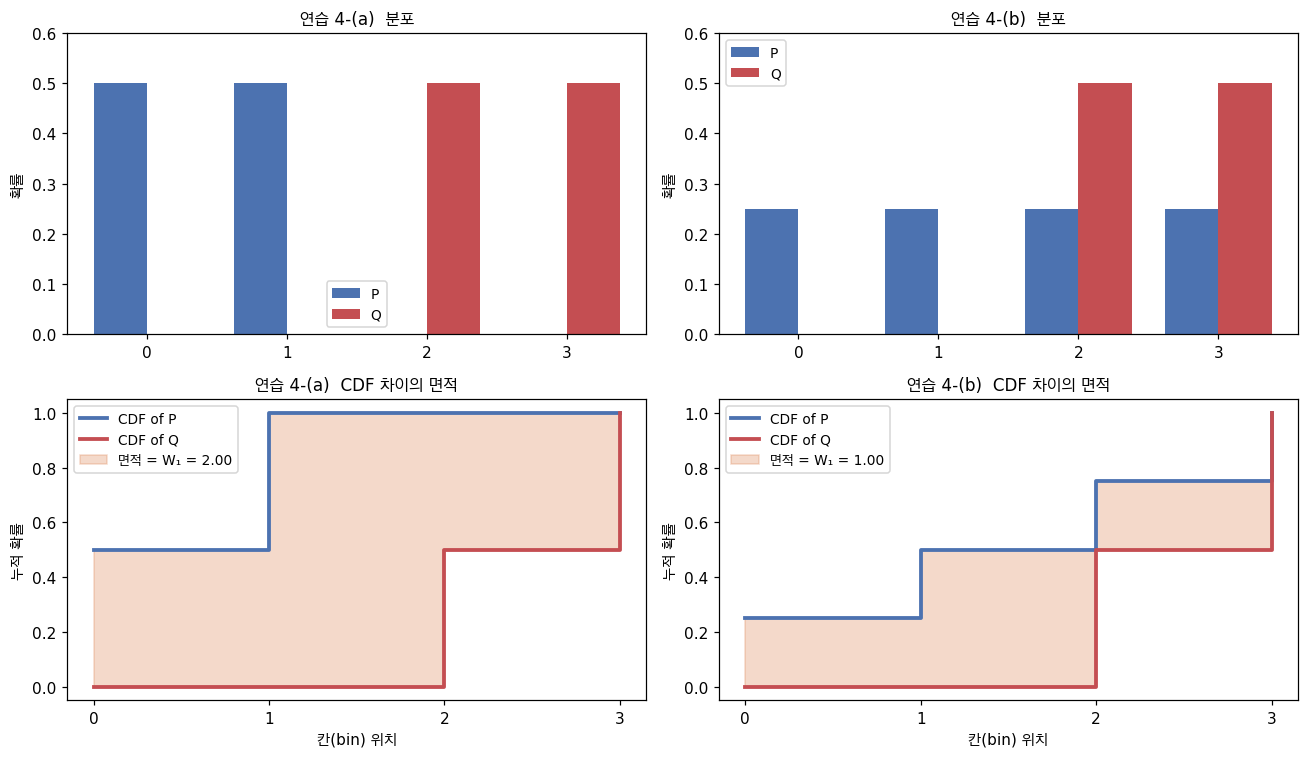

연습 4-(a): W₁ = 2.0000
연습 4-(b): W₁ = 1.0000

=> (a)가 더 크다. 질량 전부를 2칸씩 옮겨야 하기 때문.
   (b)는 이미 절반이 제자리 근처에 있어 옮길 거리가 짧다.


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
cases = [([0.5, 0.5, 0, 0], [0, 0, 0.5, 0.5], "연습 4-(a)"),
         ([0.25, 0.25, 0.25, 0.25], [0, 0, 0.5, 0.5], "연습 4-(b)")]

for col, (p, q, tag) in enumerate(cases):
    idx = np.arange(len(p))
    ax = axes[0, col]
    w = 0.38
    ax.bar(idx - w/2, p, width=w, color="#4c72b0", label="P")
    ax.bar(idx + w/2, q, width=w, color="#c44e52", label="Q")
    ax.set_title(f"{tag}  분포", fontsize=11)
    ax.set_xticks(idx); ax.set_ylim(0, 0.6); ax.legend(fontsize=9)
    ax.set_ylabel("확률")

    ax = axes[1, col]
    cp, cq = np.cumsum(p), np.cumsum(q)
    ax.step(idx, cp, where="post", lw=2.5, color="#4c72b0", label="CDF of P")
    ax.step(idx, cq, where="post", lw=2.5, color="#c44e52", label="CDF of Q")
    ax.fill_between(idx, cp, cq, step="post", alpha=0.3, color="#dd8452",
                    label=f"면적 = W₁ = {wasserstein_1d(p, q):.2f}")
    ax.set_xticks(idx); ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{tag}  CDF 차이의 면적", fontsize=11)
    ax.legend(fontsize=9, loc="upper left")
    ax.set_xlabel("칸(bin) 위치"); ax.set_ylabel("누적 확률")

plt.tight_layout()
plt.show()

for p, q, tag in cases:
    print(f"{tag}: W₁ = {wasserstein_1d(p, q):.4f}")
print("\n=> (a)가 더 크다. 질량 전부를 2칸씩 옮겨야 하기 때문.")
print("   (b)는 이미 절반이 제자리 근처에 있어 옮길 거리가 짧다.")

## 9️⃣ 🔨 Build It — 같은 데이터, 다른 척도, 다른 이웃

이 레슨의 결론을 한 장으로 보여주는 실험이다.

**하나의 질의점, 하나의 데이터셋. 그런데 척도를 바꾸면 "가장 가까운 점"이 바뀐다.**

아래에서는 L1 · L2 · L∞ · 코사인이 **각각 다른 점을 최근접 이웃으로 고르는** 데이터를
직접 찾아낸 뒤(무작위 탐색, 시드 고정), 왜 그런지 표로 확인한다.

In [18]:
def l1_distance(a, b):
    return l1_norm(diff(a, b))

def l2_distance(a, b):
    return l2_norm(diff(a, b))

def linf_distance(a, b):
    return linf_norm(diff(a, b))

METRICS = {
    "L1": l1_distance,
    "L2": l2_distance,
    "L∞": linf_distance,
    "코사인": cosine_distance,
}

def nearest_neighbor(query, dataset, metric):
    dists = [metric(query, p) for p in dataset]
    return int(np.argmin(dists)), dists

# 네 척도가 서로 다른 점을 고르는 데이터셋을 무작위 탐색으로 찾는다
rng = np.random.default_rng(11)
query = [1.0, 1.0]
found = None
for trial in range(200_000):
    pts = np.round(rng.uniform(0.05, 4.0, size=(5, 2)), 2).tolist()
    winners = {name: nearest_neighbor(query, pts, m)[0] for name, m in METRICS.items()}
    if len(set(winners.values())) == 4:
        found = (pts, winners, trial)
        break

pts, winners, trial = found
print(f"{trial + 1}번째 시도에서 네 척도가 모두 다른 답을 내는 데이터셋을 찾았다.\n")
print(f"질의점 q = {query}\n")
print(f"{'점':<6}{'좌표':<16}{'L1':>10}{'L2':>10}{'L∞':>10}{'코사인거리':>14}")
print("-" * 68)
for i, p in enumerate(pts):
    marks = "".join(f" ←{n}" for n, w in winners.items() if w == i)
    print(f"P{i:<5}{str(p):<16}{l1_distance(query,p):>10.4f}{l2_distance(query,p):>10.4f}"
          f"{linf_distance(query,p):>10.4f}{cosine_distance(query,p):>14.4f}{marks}")
print()
for name, idx in winners.items():
    print(f"  {name:<5} 최근접 이웃 -> P{idx} {pts[idx]}")
print("\n💡 '가장 가까운 이웃'은 데이터의 속성이 아니라 당신이 고른 척도의 속성이다.")

224번째 시도에서 네 척도가 모두 다른 답을 내는 데이터셋을 찾았다.

질의점 q = [1.0, 1.0]

점     좌표                      L1        L2        L∞         코사인거리
--------------------------------------------------------------------
P0    [3.86, 3.76]        5.6200    3.9746    2.8600        0.0001 ←코사인
P1    [2.64, 0.58]        2.0600    1.6929    1.6400        0.1576 ←L2
P2    [2.58, 2.15]        2.7300    1.9542    1.5800        0.0041 ←L∞
P3    [2.82, 1.12]        1.9400    1.8240    1.8200        0.0818 ←L1
P4    [3.97, 1.42]        3.3900    2.9995    2.9700        0.0961

  L1    최근접 이웃 -> P3 [2.82, 1.12]
  L2    최근접 이웃 -> P1 [2.64, 0.58]
  L∞    최근접 이웃 -> P2 [2.58, 2.15]
  코사인   최근접 이웃 -> P0 [3.86, 3.76]

💡 '가장 가까운 이웃'은 데이터의 속성이 아니라 당신이 고른 척도의 속성이다.


### 🖼️ 그림 8 — 척도마다 다른 최근접 이웃

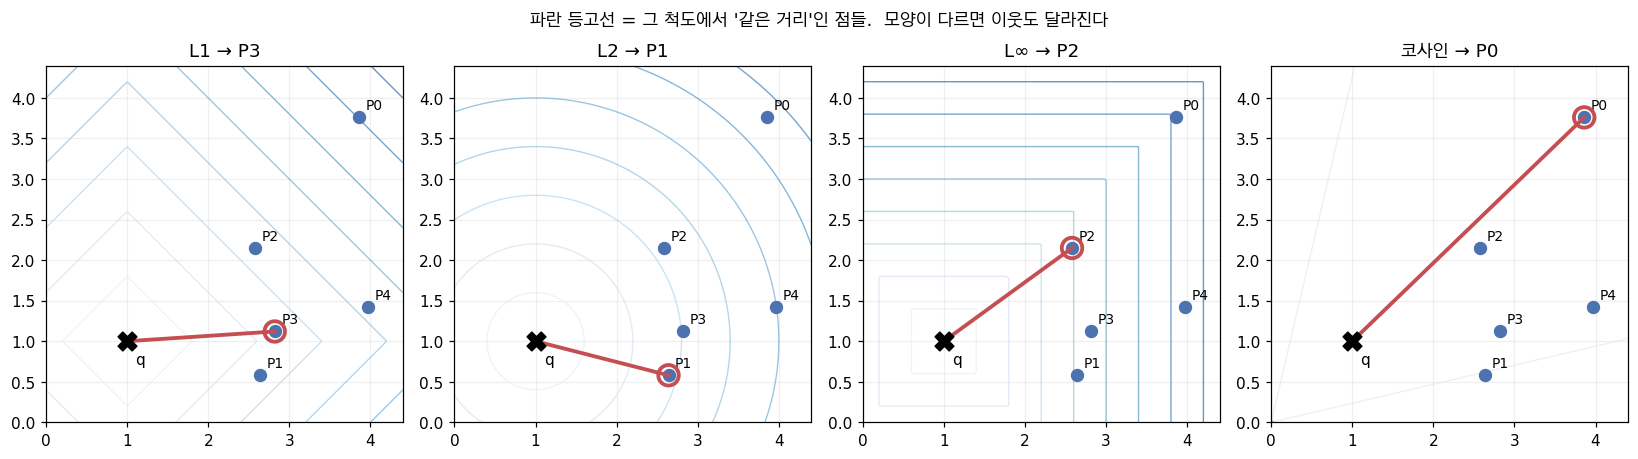

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.1))
P = np.array(pts)
q = np.array(query)

for ax, (name, metric) in zip(axes, METRICS.items()):
    idx = winners[name]
    # 척도별 등거리 윤곽선
    gx, gy = np.meshgrid(np.linspace(0, 4.4, 150), np.linspace(0, 4.4, 150))
    grid = np.stack([gx.ravel(), gy.ravel()], axis=1)
    d = np.array([metric(list(q), list(g)) for g in grid]).reshape(gx.shape)
    ax.contour(gx, gy, d, levels=8, cmap="Blues", alpha=0.6, linewidths=0.9)

    ax.scatter(P[:, 0], P[:, 1], s=60, color="#4c72b0", zorder=4)
    for i, p in enumerate(P):
        ax.text(p[0] + 0.08, p[1] + 0.1, f"P{i}", fontsize=9)
    ax.scatter(*q, s=150, marker="X", color="black", zorder=6)
    ax.text(q[0] + 0.1, q[1] - 0.28, "q", fontsize=10)
    ax.plot([q[0], P[idx, 0]], [q[1], P[idx, 1]], color="#c44e52", lw=2.5, zorder=5)
    ax.scatter(*P[idx], s=180, facecolor="none", edgecolor="#c44e52", lw=2.5, zorder=6)
    ax.set_title(f"{name} → P{idx}", fontsize=12)
    ax.set_xlim(0, 4.4); ax.set_ylim(0, 4.4); ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.suptitle("파란 등고선 = 그 척도에서 '같은 거리'인 점들.  모양이 다르면 이웃도 달라진다",
             fontsize=12)
plt.tight_layout()
plt.show()

## 🔟 🏭 Use It — 임베딩 검색과 근사 최근접 이웃(ANN)

가장 흔한 실전 용도: **벡터 데이터베이스에서 비슷한 항목 찾기.**

`model.encode(text)` 를 호출한 뒤 벡터 DB를 검색할 때 내부에서 벌어지는 일이 바로 이것이다.
임베딩 모델이 텍스트를 벡터로 만들고, DB가 질의 벡터와 저장된 벡터 사이의
**코사인 유사도(또는 내적)** 를 계산한다. 전부 다 계산하지 않기 위해 **ANN 알고리즘**을 쓴다.

### 📐 근사 최근접 이웃 (ANN)

정확한 최근접 탐색은 질의당 `O(n·d)`. 대규모에서는 너무 느리다.
ANN은 **아주 약간의 정확도**를 내주고 **엄청난 속도**를 얻는다.

| 알고리즘 | 접근 방식 | 쓰는 곳 |
| --- | --- | --- |
| KD-tree | 축 정렬 공간 분할 | scikit-learn (저차원) |
| Ball tree | 중첩된 초구 | scikit-learn (중간 차원) |
| LSH | 무작위 해시 투영 | 중복 문서 탐지 |
| **HNSW** | 계층적 내비게이션 스몰월드 그래프 | **FAISS, Qdrant, Weaviate** |
| IVF | 클러스터 기반 역색인 | FAISS (수십억 규모) |
| Product Quantization | 벡터 압축 후 압축 공간에서 탐색 | FAISS (메모리 제약) |

**HNSW**가 현대 벡터 DB의 지배적 알고리즘이다. 각 노드가 근사 최근접 이웃과 연결된 다층 그래프를 만들고,
**위층(성기고 긴 점프)에서 시작해 아래층(촘촘하고 짧은 점프)으로 내려가며** 탐색한다.

In [20]:
def cosine_similarity_matrix(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    Xn = X / norms
    return Xn @ Xn.T

rng = np.random.default_rng(5)
D = 768
# 주제 3개를 만들고, 각 주제에서 문서를 생성한다. '길이'는 스케일로 표현한다.
topics = rng.normal(size=(3, D))
docs, meta = [], []
for topic_id in range(3):
    for k in range(4):
        length_scale = [0.3, 1.0, 3.0, 8.0][k]        # 짧은 문서 ~ 아주 긴 문서
        v = topics[topic_id] + 0.35 * rng.normal(size=D)
        docs.append(v / np.linalg.norm(v) * length_scale)
        meta.append(f"주제{topic_id}-길이{length_scale:g}")
docs = np.array(docs)

query = docs[1]                                        # 주제0, 보통 길이 문서를 질의로
cos_scores = cosine_similarity_matrix(np.vstack([query, docs]))[0, 1:]
l2_scores = np.linalg.norm(docs - query, axis=1)

cos_rank = np.argsort(-cos_scores)
l2_rank = np.argsort(l2_scores)

print(f"질의 문서: {meta[1]}\n")
print(f"{'순위':<6}{'코사인 Top-5':<24}{'유사도':>10}   |   {'L2 Top-5':<24}{'거리':>10}")
print("-" * 88)
for r in range(5):
    i, j = cos_rank[r], l2_rank[r]
    print(f"{r+1:<6}{meta[i]:<24}{cos_scores[i]:>10.4f}   |   {meta[j]:<24}{l2_scores[j]:>10.4f}")

same_topic = lambda name: name.startswith("주제0")
print(f"\n코사인 Top-5 중 같은 주제: {sum(same_topic(meta[i]) for i in cos_rank[:5])}/5")
print(f"L2     Top-5 중 같은 주제: {sum(same_topic(meta[j]) for j in l2_rank[:5])}/5")
print("\n=> L2는 '길이가 비슷한 문서'를 위로 올린다. 코사인은 '주제가 같은 문서'를 올린다.")
print("   임베딩 검색에서 코사인이 기본값인 이유.")

질의 문서: 주제0-길이1

순위    코사인 Top-5                      유사도   |   L2 Top-5                        거리
----------------------------------------------------------------------------------------
1     주제0-길이1                     1.0000   |   주제0-길이1                     0.0000
2     주제0-길이8                     0.8926   |   주제0-길이0.3                   0.7491
3     주제0-길이3                     0.8905   |   주제2-길이0.3                   1.0381
4     주제0-길이0.3                   0.8815   |   주제1-길이0.3                   1.0505
5     주제2-길이8                     0.0232   |   주제2-길이1                     1.4028

코사인 Top-5 중 같은 주제: 4/5
L2     Top-5 중 같은 주제: 2/5

=> L2는 '길이가 비슷한 문서'를 위로 올린다. 코사인은 '주제가 같은 문서'를 올린다.
   임베딩 검색에서 코사인이 기본값인 이유.


In [21]:
# 🏭 정규화된 임베딩에서는 코사인 · 내적 · L2가 같은 순위를 준다 (실무에서 자주 쓰는 사실)
docs_n = docs / np.linalg.norm(docs, axis=1, keepdims=True)
q_n = query / np.linalg.norm(query)

cos_n = docs_n @ q_n
dot_n = docs_n @ q_n
l2_n = np.linalg.norm(docs_n - q_n, axis=1)

print("L2 정규화 후 세 척도의 순위 비교")
print(f"  코사인 순위 : {list(np.argsort(-cos_n))}")
print(f"  내적   순위 : {list(np.argsort(-dot_n))}")
print(f"  L2     순위 : {list(np.argsort(l2_n))}")
print(f"\n  세 순위가 동일한가? "
      f"{list(np.argsort(-cos_n)) == list(np.argsort(-dot_n)) == list(np.argsort(l2_n))}")
print("\n  이유: ‖a-b‖² = ‖a‖² + ‖b‖² - 2a·b = 2 - 2·cos  (단위벡터일 때)")
print("        -> L2 거리는 코사인 유사도의 단조 감소 함수라서 순위가 뒤집히지 않는다.")
a, b = docs_n[0], docs_n[5]
print(f"\n  검증: ‖a-b‖² = {np.linalg.norm(a-b)**2:.6f},  2-2cos = {2 - 2*(a@b):.6f}")

L2 정규화 후 세 척도의 순위 비교
  코사인 순위 : [1, 3, 2, 0, 11, 8, 9, 10, 5, 4, 6, 7]
  내적   순위 : [1, 3, 2, 0, 11, 8, 9, 10, 5, 4, 6, 7]
  L2     순위 : [1, 3, 2, 0, 11, 8, 9, 10, 5, 4, 6, 7]

  세 순위가 동일한가? True

  이유: ‖a-b‖² = ‖a‖² + ‖b‖² - 2a·b = 2 - 2·cos  (단위벡터일 때)
        -> L2 거리는 코사인 유사도의 단조 감소 함수라서 순위가 뒤집히지 않는다.

  검증: ‖a-b‖² = 2.027937,  2-2cos = 2.027937


## 1️⃣1️⃣ 정규화와의 연결 — L1은 왜 0을 만들고 L2는 못 만드나

정규화(regularization)는 손실 함수에 **가중치의 노름 벌점**을 더하는 것이다.

```
L1 정규화 (Lasso):  loss + λ‖w‖₁
  -> 희소한 가중치. 일부가 정확히 0이 된다.
  -> 자동 특징 선택.
  -> 0에서 미분 불가능(뾰족한 해).

L2 정규화 (Ridge / weight decay):  loss + λ‖w‖₂²
  -> 작은 가중치. 모두 0 쪽으로 비례해 줄어든다.
  -> 특징 선택은 안 됨(정확히 0이 되지 않음).
  -> 어디서나 매끄럽다.

Elastic Net:  loss + λ₁‖w‖₁ + λ₂‖w‖₂²
  -> L1의 희소성 + L2의 안정성. 상관된 특징 그룹을 함께 살리거나 함께 버린다.
```

### 🧸 비유 — 예산을 어떤 모양의 지갑에 담느냐

가중치 공간에서 **"쓸 수 있는 예산"** 을 그리면:

- **L1 = 다이아몬드 지갑** → 꼭짓점이 **축 위**에 있다
- **L2 = 원형 지갑** → 매끄러워서 꼭짓점이 없다

손실 함수의 등고선(타원)이 지갑에 **처음 닿는 지점**이 해다.
**다이아몬드는 뾰족한 꼭짓점에서 먼저 닿기 쉽고, 그 꼭짓점은 축 위 = 한 가중치가 0이다.**
원에는 꼭짓점이 없으니 매끄러운 점에서 닿고, 두 가중치 모두 0이 아니다.

> **→ 3절에서 본 "L1 단위 볼의 꼭짓점이 축 위에 있다"가 여기서 희소성이 된다.**

### 🖼️ 그림 9 — 다이아몬드는 꼭짓점에서, 원은 매끄러운 곳에서 만난다

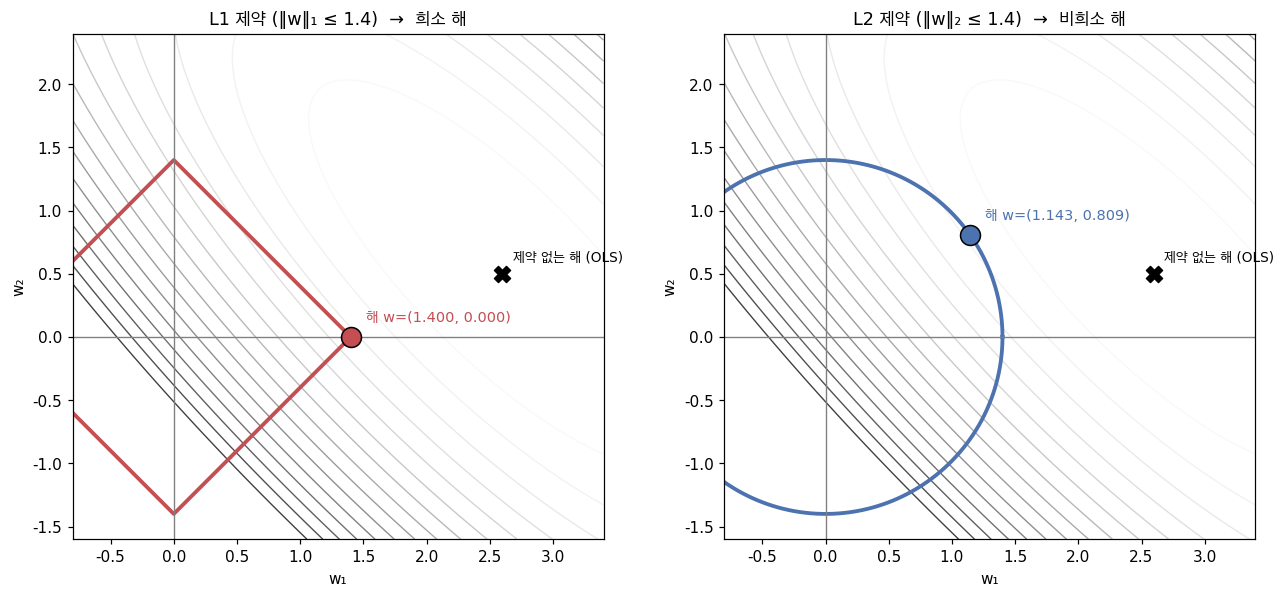

L1 해: w = (1.4000, 0.0000)   |w|<1e-3 인 성분 수: 1
L2 해: w = (1.1428, 0.8088)   |w|<1e-3 인 성분 수: 0

=> L1은 꼭짓점(축 위)에서 만나 w₂를 정확히 0으로 만든다 = 특징 선택.
   L2는 매끄러운 곳에서 만나 둘 다 작지만 0은 아니다 = 축소(shrinkage)만.


In [22]:
# 최소제곱 손실의 등고선: (w - w_ols)ᵀ A (w - w_ols)
w_ols = np.array([2.6, 0.5])
A = np.array([[1.0, 0.8], [0.8, 1.0]])        # 상관된 특징 -> 길쭉한 타원

def loss(w):
    d = np.asarray(w) - w_ols
    return float(d @ A @ d)

def constrained_solution(t, p):
    # 제약 ‖w‖_p ≤ t 의 경계를 촘촘히 훑어 손실이 가장 작은 점을 찾는다
    th = np.linspace(0, 2 * np.pi, 4000)
    c, s = np.cos(th), np.sin(th)
    if p == 1:
        r = t / (np.abs(c) + np.abs(s))
    else:
        r = np.full_like(th, t)
    W = np.stack([r * c, r * s], axis=1)
    vals = np.array([loss(w) for w in W])
    return W[int(np.argmin(vals))]

t = 1.4
w_l1 = constrained_solution(t, 1)
w_l2 = constrained_solution(t, 2)

gx, gy = np.meshgrid(np.linspace(-0.8, 3.4, 320), np.linspace(-1.6, 2.4, 320))
Z = np.array([loss([x, y]) for x, y in zip(gx.ravel(), gy.ravel())]).reshape(gx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for ax, (title, w_star, color) in zip(axes, [
        (f"L1 제약 (‖w‖₁ ≤ {t})  →  희소 해", w_l1, "#c44e52"),
        (f"L2 제약 (‖w‖₂ ≤ {t})  →  비희소 해", w_l2, "#4c72b0")]):
    ax.contour(gx, gy, Z, levels=np.linspace(0.05, 12, 16), cmap="Greys", alpha=0.75, linewidths=0.9)
    if "L1" in title:
        ax.plot([t, 0, -t, 0, t], [0, t, 0, -t, 0], lw=2.5, color=color)
    else:
        th = np.linspace(0, 2 * np.pi, 400)
        ax.plot(t * np.cos(th), t * np.sin(th), lw=2.5, color=color)
    ax.scatter(*w_ols, s=110, marker="X", color="black", zorder=6)
    ax.text(w_ols[0] + 0.08, w_ols[1] + 0.1, "제약 없는 해 (OLS)", fontsize=9)
    ax.scatter(*w_star, s=170, color=color, edgecolor="black", zorder=7)
    ax.text(w_star[0] + 0.12, w_star[1] + 0.12,
            f"해 w=({w_star[0]:.3f}, {w_star[1]:.3f})", fontsize=9.5, color=color)
    ax.axhline(0, color="gray", lw=0.9); ax.axvline(0, color="gray", lw=0.9)
    ax.set_xlim(-0.8, 3.4); ax.set_ylim(-1.6, 2.4); ax.set_aspect("equal")
    ax.set_xlabel("w₁"); ax.set_ylabel("w₂")
    ax.set_title(title, fontsize=11.5)
plt.tight_layout()
plt.show()

print(f"L1 해: w = ({w_l1[0]:.4f}, {w_l1[1]:.4f})   |w|<1e-3 인 성분 수: {int(np.sum(np.abs(w_l1) < 1e-3))}")
print(f"L2 해: w = ({w_l2[0]:.4f}, {w_l2[1]:.4f})   |w|<1e-3 인 성분 수: {int(np.sum(np.abs(w_l2) < 1e-3))}")
print("\n=> L1은 꼭짓점(축 위)에서 만나 w₂를 정확히 0으로 만든다 = 특징 선택.")
print("   L2는 매끄러운 곳에서 만나 둘 다 작지만 0은 아니다 = 축소(shrinkage)만.")

In [23]:
# 🏭 λ를 키우면 각 가중치가 어떻게 죽는가 — 좌표 하강법으로 직접 학습
rng = np.random.default_rng(0)
n, d = 200, 8
X = rng.normal(size=(n, d))
true_w = np.array([3.0, -2.0, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0])   # 진짜로는 3개만 의미 있음
y = X @ true_w + 0.5 * rng.normal(size=n)

def soft_threshold(rho, lam):
    return np.sign(rho) * max(abs(rho) - lam, 0.0)

def lasso(X, y, lam, iters=300):
    w = np.zeros(X.shape[1])
    for _ in range(iters):
        for j in range(X.shape[1]):
            r = y - X @ w + X[:, j] * w[j]
            w[j] = soft_threshold(X[:, j] @ r / len(y), lam) / (X[:, j] @ X[:, j] / len(y))
    return w

def ridge(X, y, lam):
    d = X.shape[1]
    return np.linalg.solve(X.T @ X / len(y) + lam * np.eye(d), X.T @ y / len(y))

print(f"진짜 가중치: {true_w}  (0이 5개)\n")
print(f"{'λ':>8}  {'LASSO에서 0이 된 개수':>22}  {'Ridge에서 0이 된 개수':>22}")
print("-" * 58)
for lam in [0.01, 0.1, 0.3, 0.6, 1.0]:
    wl, wr = lasso(X, y, lam), ridge(X, y, lam)
    print(f"{lam:>8.2f}  {int(np.sum(np.abs(wl) < 1e-8)):>22}  {int(np.sum(np.abs(wr) < 1e-8)):>22}")

wl, wr = lasso(X, y, 0.3), ridge(X, y, 0.3)
print(f"\nλ=0.3 일 때")
print(f"  LASSO w = {np.round(wl, 3)}")
print(f"  Ridge w = {np.round(wr, 3)}")
print("\n=> LASSO는 쓸모없는 가중치를 '정확히 0'으로 죽인다. Ridge는 작게 만들 뿐 죽이지 못한다.")

진짜 가중치: [ 3.  -2.   1.5  0.   0.   0.   0.   0. ]  (0이 5개)

       λ         LASSO에서 0이 된 개수         Ridge에서 0이 된 개수
----------------------------------------------------------
    0.01                       2                       0
    0.10                       5                       0
    0.30                       5                       0
    0.60                       5                       0
    1.00                       5                       0

λ=0.3 일 때
  LASSO w = [ 2.653 -1.629  1.054 -0.     0.     0.     0.     0.   ]
  Ridge w = [ 2.229 -1.474  0.984 -0.078  0.048  0.047  0.06   0.077]

=> LASSO는 쓸모없는 가중치를 '정확히 0'으로 죽인다. Ridge는 작게 만들 뿐 죽이지 못한다.


## 1️⃣2️⃣ 손실 함수와의 연결

**손실 함수는 예측과 정답 사이에 적용된 거리 함수다.** 그게 전부다.

| 손실 | 쓰는 거리 | 성격 |
| --- | --- | --- |
| **MSE** | L2 제곱 | 큰 오차를 크게 벌한다 (이상치에 민감) |
| **MAE** | L1 | 모든 오차를 동등하게 벌한다 (이상치에 강건) |
| **Huber** | 작으면 L2, 크면 L1 | 두 장점 결합: 강건 + 0 근처에서 매끄러운 기울기 |
| **Cross-entropy** | KL 발산 | 분포 불일치를 잰다 |
| **Hinge** | `max(0, margin − d)` | 마진 안쪽만 벌한다 |
| **Triplet** | 보통 L2 | 양성은 당기고 음성은 민다 |
| **Contrastive** | L2 | 비슷한 쌍은 가깝게, 다른 쌍은 마진 밖으로 |

$$\text{Huber}_\delta(e) = \begin{cases}
\tfrac{1}{2}e^2 & |e| \le \delta \\
\delta(|e| - \tfrac{1}{2}\delta) & |e| > \delta
\end{cases}$$

In [24]:
def mse_loss(y, yhat):
    return float(np.mean((np.asarray(y) - np.asarray(yhat)) ** 2))

def mae_loss(y, yhat):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(yhat))))

def huber_loss(y, yhat, delta=1.0):
    e = np.abs(np.asarray(y) - np.asarray(yhat))
    return float(np.mean(np.where(e <= delta, 0.5 * e ** 2, delta * (e - 0.5 * delta))))

rng = np.random.default_rng(1)
y = rng.normal(size=100)
pred = y + 0.2 * rng.normal(size=100)          # 대체로 잘 맞는 예측
pred_out = pred.copy()
pred_out[0] += 12.0                            # 이상치 하나

print(f"{'상황':<22}{'MSE':>12}{'MAE':>12}{'Huber(δ=1)':>14}")
print("-" * 62)
print(f"{'정상':<22}{mse_loss(y,pred):>12.4f}{mae_loss(y,pred):>12.4f}{huber_loss(y,pred):>14.4f}")
print(f"{'이상치 1개 추가':<20}{mse_loss(y,pred_out):>12.4f}{mae_loss(y,pred_out):>12.4f}"
      f"{huber_loss(y,pred_out):>14.4f}")
r = lambda a, b: b / a
print(f"{'증가 배율':<22}{r(mse_loss(y,pred),mse_loss(y,pred_out)):>11.1f}x"
      f"{r(mae_loss(y,pred),mae_loss(y,pred_out)):>11.1f}x"
      f"{r(huber_loss(y,pred),huber_loss(y,pred_out)):>13.1f}x")
print("\n=> 100개 중 이상치 딱 하나에 MSE는 폭발하고, MAE/Huber는 훨씬 덜 흔들린다.")

상황                             MSE         MAE    Huber(δ=1)
--------------------------------------------------------------
정상                          0.0396      0.1544        0.0198
이상치 1개 추가                 1.4483      0.2718        0.1334
증가 배율                        36.6x        1.8x          6.7x

=> 100개 중 이상치 딱 하나에 MSE는 폭발하고, MAE/Huber는 훨씬 덜 흔들린다.


### 🖼️ 그림 10 — 오차 하나를 얼마나 벌하는가

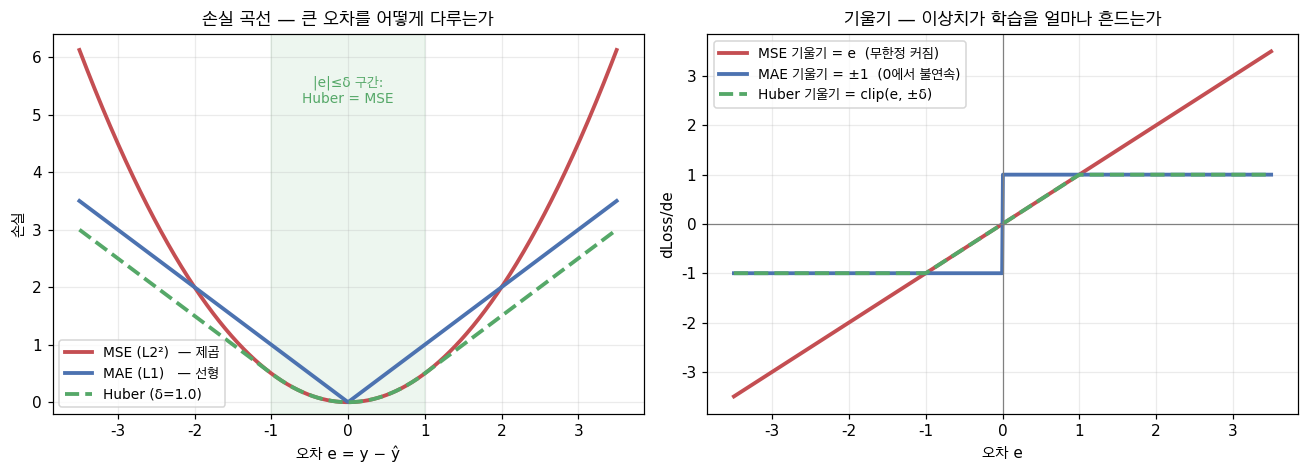

MSE : 오차가 10이면 기울기도 10. 이상치 하나가 업데이트를 지배한다.
MAE : 기울기가 항상 ±1이라 강건하지만, 0 근처에서 매끄럽지 않아 수렴이 덜 곱다.
Huber: 작은 오차는 MSE처럼(매끄럽게), 큰 오차는 MAE처럼(강건하게). 그래서 실무 기본값.


In [25]:
e = np.linspace(-3.5, 3.5, 700)
delta = 1.0
mse_c = 0.5 * e ** 2
mae_c = np.abs(e)
hub_c = np.where(np.abs(e) <= delta, 0.5 * e ** 2, delta * (np.abs(e) - 0.5 * delta))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.plot(e, mse_c, lw=2.5, color="#c44e52", label="MSE (L2²)  — 제곱")
ax1.plot(e, mae_c, lw=2.5, color="#4c72b0", label="MAE (L1)   — 선형")
ax1.plot(e, hub_c, lw=2.5, ls="--", color="#55a868", label=f"Huber (δ={delta})")
ax1.axvspan(-delta, delta, alpha=0.1, color="#55a868")
ax1.text(0, 5.2, "|e|≤δ 구간:\nHuber = MSE", ha="center", fontsize=9, color="#55a868")
ax1.set_xlabel("오차 e = y − ŷ"); ax1.set_ylabel("손실")
ax1.set_title("손실 곡선 — 큰 오차를 어떻게 다루는가")
ax1.legend(fontsize=9); ax1.grid(alpha=0.25); ax1.set_ylim(-0.2, 6.4)

# 기울기(= 학습 신호)
ax2.plot(e, e, lw=2.5, color="#c44e52", label="MSE 기울기 = e  (무한정 커짐)")
ax2.plot(e, np.sign(e), lw=2.5, color="#4c72b0", label="MAE 기울기 = ±1  (0에서 불연속)")
ax2.plot(e, np.clip(e, -delta, delta), lw=2.5, ls="--", color="#55a868",
         label="Huber 기울기 = clip(e, ±δ)")
ax2.axhline(0, color="gray", lw=0.8); ax2.axvline(0, color="gray", lw=0.8)
ax2.set_xlabel("오차 e"); ax2.set_ylabel("dLoss/de")
ax2.set_title("기울기 — 이상치가 학습을 얼마나 흔드는가")
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("MSE : 오차가 10이면 기울기도 10. 이상치 하나가 업데이트를 지배한다.")
print("MAE : 기울기가 항상 ±1이라 강건하지만, 0 근처에서 매끄럽지 않아 수렴이 덜 곱다.")
print("Huber: 작은 오차는 MSE처럼(매끄럽게), 큰 오차는 MAE처럼(강건하게). 그래서 실무 기본값.")

## 1️⃣3️⃣ 📝 연습문제 (풀이 포함)

1. (1,2,3)과 (4,0,6)의 L1 · L2 · L∞ 거리를 계산하고, 항상 `L∞ ≤ L2 ≤ L1` 임을 확인·증명하라.
2. 코사인 유사도는 높은데(>0.9) L2 거리는 큰(>10) 벡터 쌍을 만들어라. 반대 경우(코사인 <0.3, L2 <0.5)도.
3. 데이터셋과 질의점을 받아 L1·L2·코사인·마할라노비스 최근접 이웃을 반환하는 함수를 만들고,
   **네 척도가 모두 다른 답을 내는** 데이터를 찾아라.
4. `[0.5,0.5,0,0]` vs `[0,0,0.5,0.5]` 의 Wasserstein 거리를 CDF 방법으로 손으로 계산하라.
   `[0.25]*4` vs `[0,0,0.5,0.5]` 도. 어느 쪽이 큰가, 왜인가?
5. MinHash로 근사 자카드를 구현하라. 무작위 집합 100개의 정확한 자카드와,
   해시 함수 50·100·200개일 때의 근사값을 비교해 오차를 그려라.

In [26]:
print("=" * 70)
print("연습 1 — L∞ ≤ L2 ≤ L1")
print("=" * 70)
a, b = [1.0, 2.0, 3.0], [4.0, 0.0, 6.0]
d = diff(a, b)
print(f"a={a}, b={b}, 차이={d}")
print(f"  L1 = |−3|+|2|+|−3| = {l1_distance(a,b):.6f}")
print(f"  L2 = √(9+4+9) = √22 = {l2_distance(a,b):.6f}")
print(f"  L∞ = max(3,2,3)     = {linf_distance(a,b):.6f}")
print(f"  L∞ ≤ L2 ≤ L1 ? {linf_distance(a,b) <= l2_distance(a,b) <= l1_distance(a,b)}")

print("\n무작위 10,000쌍으로 반례가 있는지 확인")
rng = np.random.default_rng(7)
V = rng.normal(size=(10_000, 6)) * 10
W = rng.normal(size=(10_000, 6)) * 10
D = V - W
L1 = np.abs(D).sum(1); L2 = np.sqrt((D ** 2).sum(1)); Li = np.abs(D).max(1)
print(f"  L∞ ≤ L2 위반 건수: {int(np.sum(Li > L2 + 1e-12))}")
print(f"  L2 ≤ L1 위반 건수: {int(np.sum(L2 > L1 + 1e-12))}")

proof = [
    "증명 스케치",
    "  (1) L∞ ≤ L2 :  L2² = Σxᵢ² ≥ (max|xᵢ|)² = L∞²",
    "                 — 제곱합에는 최댓값의 제곱이 항으로 들어 있으므로",
    "  (2) L2 ≤ L1 :  L1² = (Σ|xᵢ|)² = Σxᵢ² + 2·Σ(i<j)|xᵢ||xⱼ| ≥ Σxᵢ² = L2²",
    "                 — 교차항이 모두 0 이상이므로",
    "  등호 조건: 두 경우 모두 '성분 하나만 0이 아닐 때'",
]
print("\n" + "\n".join(proof))

연습 1 — L∞ ≤ L2 ≤ L1
a=[1.0, 2.0, 3.0], b=[4.0, 0.0, 6.0], 차이=[-3.0, 2.0, -3.0]
  L1 = |−3|+|2|+|−3| = 8.000000
  L2 = √(9+4+9) = √22 = 4.690416
  L∞ = max(3,2,3)     = 3.000000
  L∞ ≤ L2 ≤ L1 ? True

무작위 10,000쌍으로 반례가 있는지 확인
  L∞ ≤ L2 위반 건수: 0
  L2 ≤ L1 위반 건수: 0

증명 스케치
  (1) L∞ ≤ L2 :  L2² = Σxᵢ² ≥ (max|xᵢ|)² = L∞²
                 — 제곱합에는 최댓값의 제곱이 항으로 들어 있으므로
  (2) L2 ≤ L1 :  L1² = (Σ|xᵢ|)² = Σxᵢ² + 2·Σ(i<j)|xᵢ||xⱼ| ≥ Σxᵢ² = L2²
                 — 교차항이 모두 0 이상이므로
  등호 조건: 두 경우 모두 '성분 하나만 0이 아닐 때'


In [27]:
print("=" * 70)
print("연습 2 — 코사인과 L2는 서로를 구속하지 않는다")
print("=" * 70)

# (a) 코사인 높고 L2 큰 쌍: 같은 방향, 길이만 다르게
a = np.array([1.0, 1.0, 1.0])
b = a * 12.0
print(f"(a) a={a}, b={b}")
print(f"    코사인 유사도 = {cosine_similarity(list(a), list(b)):.4f}  (> 0.9 ✅)")
print(f"    L2 거리       = {np.linalg.norm(a-b):.4f}  (> 10 ✅)")
print("    기하학적 해석: 같은 반직선 위에 있지만 원점에서의 거리가 크게 다르다.")

# (b) 코사인 낮고 L2 작은 쌍: 원점 근처의 거의 수직인 짧은 벡터 둘
c = np.array([0.20, 0.02, 0.0])
e = np.array([0.02, 0.20, 0.0])
print(f"\n(b) c={c}, d={e}")
print(f"    코사인 유사도 = {cosine_similarity(list(c), list(e)):.4f}  (< 0.3 ✅)")
print(f"    L2 거리       = {np.linalg.norm(c-e):.4f}  (< 0.5 ✅)")
print("    기하학적 해석: 둘 다 원점에 아주 가까워서 각도가 커도 실제 간격은 좁다.")
print("\n💡 그래서 임베딩을 L2 정규화하면 두 척도가 일치하게 된다(10절).")

연습 2 — 코사인과 L2는 서로를 구속하지 않는다
(a) a=[1. 1. 1.], b=[12. 12. 12.]
    코사인 유사도 = 1.0000  (> 0.9 ✅)
    L2 거리       = 19.0526  (> 10 ✅)
    기하학적 해석: 같은 반직선 위에 있지만 원점에서의 거리가 크게 다르다.

(b) c=[0.2  0.02 0.  ], d=[0.02 0.2  0.  ]
    코사인 유사도 = 0.1980  (< 0.3 ✅)
    L2 거리       = 0.2546  (< 0.5 ✅)
    기하학적 해석: 둘 다 원점에 아주 가까워서 각도가 커도 실제 간격은 좁다.

💡 그래서 임베딩을 L2 정규화하면 두 척도가 일치하게 된다(10절).


In [28]:
print("=" * 70)
print("연습 3 — 네 척도(마할라노비스 포함)가 모두 다른 답을 내는 데이터")
print("=" * 70)

rng = np.random.default_rng(202)
cov_data = rng.multivariate_normal([1.5, 1.5], [[1.0, 0.85], [0.85, 1.0]], size=400)
S_inv3 = np.linalg.inv(np.cov(cov_data.T))

def all_metrics(q, p):
    return {
        "L1": l1_distance(q, p),
        "L2": l2_distance(q, p),
        "코사인": cosine_distance(q, p),
        "마할라노비스": mahalanobis(q, p, S_inv3),
    }

query = [1.5, 1.5]
found = None
for trial in range(200_000):
    pts = np.round(rng.uniform(-0.5, 4.0, size=(5, 2)), 2).tolist()
    win = {}
    for name in ["L1", "L2", "코사인", "마할라노비스"]:
        win[name] = int(np.argmin([all_metrics(query, p)[name] for p in pts]))
    if len(set(win.values())) == 4:
        found = (pts, win, trial)
        break

pts3, win3, trial3 = found
print(f"{trial3+1}번째 시도에서 발견.  질의 q = {query}\n")
print(f"{'점':<6}{'좌표':<16}{'L1':>10}{'L2':>10}{'코사인':>10}{'마할라노비스':>16}")
print("-" * 70)
for i, p in enumerate(pts3):
    m = all_metrics(query, p)
    marks = "".join(f" ←{n}" for n, w in win3.items() if w == i)
    print(f"P{i:<5}{str(p):<16}{m['L1']:>10.4f}{m['L2']:>10.4f}"
          f"{m['코사인']:>10.4f}{m['마할라노비스']:>16.4f}{marks}")
print()
for name, idx in win3.items():
    print(f"  {name:<12} -> P{idx} {pts3[idx]}")

연습 3 — 네 척도(마할라노비스 포함)가 모두 다른 답을 내는 데이터
24번째 시도에서 발견.  질의 q = [1.5, 1.5]

점     좌표                      L1        L2       코사인          마할라노비스
----------------------------------------------------------------------
P0    [3.18, 1.99]        2.1700    1.7500    0.0255          2.3959
P1    [1.3, 0.31]         1.3900    1.2067    0.1482          1.9898 ←L1
P2    [0.77, 2.36]        1.5900    1.1281    0.1084          2.9219 ←L2
P3    [2.06, 2.71]        1.7700    1.3333    0.0092          1.5417 ←마할라노비스
P4    [2.83, 3.3]         3.1300    2.2381    0.0029          1.8710 ←코사인

  L1           -> P1 [1.3, 0.31]
  L2           -> P2 [0.77, 2.36]
  코사인          -> P4 [2.83, 3.3]
  마할라노비스       -> P3 [2.06, 2.71]


In [29]:
print("=" * 70)
print("연습 4 — Wasserstein 손 계산")
print("=" * 70)

def show_cdf_calc(p, q, label):
    p, q = np.array(p), np.array(q)
    cp, cq = np.cumsum(p), np.cumsum(q)
    print(f"\n{label}")
    print(f"  P      = {p}")
    print(f"  Q      = {q}")
    print(f"  CDF_P  = {cp}")
    print(f"  CDF_Q  = {cq}")
    print(f"  |차이| = {np.abs(cp-cq)}")
    print(f"  W₁ = 마지막 칸을 뺀 |차이|의 합 = {np.abs(cp-cq)[:-1].sum():.4f}"
          f"   (함수값 {wasserstein_1d(p, q):.4f})")

show_cdf_calc([0.5, 0.5, 0, 0], [0, 0, 0.5, 0.5], "(a) [.5,.5,0,0] vs [0,0,.5,.5]")
show_cdf_calc([0.25] * 4, [0, 0, 0.5, 0.5], "(b) [.25]*4 vs [0,0,.5,.5]")

print("\n어느 쪽이 큰가?  (a) = 2.0  >  (b) = 1.0")
print("  (a): 질량 전부를 정확히 2칸씩 옮겨야 한다 -> 1.0 × 2칸 = 2")
print("  (b): 이미 절반(칸2·칸3의 0.25씩)이 목적지 근처에 있어 평균 이동 거리가 짧다")
print("  💡 Wasserstein은 '얼마나 많이'와 '얼마나 멀리'를 곱해서 잰다.")

연습 4 — Wasserstein 손 계산

(a) [.5,.5,0,0] vs [0,0,.5,.5]
  P      = [0.5 0.5 0.  0. ]
  Q      = [0.  0.  0.5 0.5]
  CDF_P  = [0.5 1.  1.  1. ]
  CDF_Q  = [0.  0.  0.5 1. ]
  |차이| = [0.5 1.  0.5 0. ]
  W₁ = 마지막 칸을 뺀 |차이|의 합 = 2.0000   (함수값 2.0000)

(b) [.25]*4 vs [0,0,.5,.5]
  P      = [0.25 0.25 0.25 0.25]
  Q      = [0.  0.  0.5 0.5]
  CDF_P  = [0.25 0.5  0.75 1.  ]
  CDF_Q  = [0.  0.  0.5 1. ]
  |차이| = [0.25 0.5  0.25 0.  ]
  W₁ = 마지막 칸을 뺀 |차이|의 합 = 1.0000   (함수값 1.0000)

어느 쪽이 큰가?  (a) = 2.0  >  (b) = 1.0
  (a): 질량 전부를 정확히 2칸씩 옮겨야 한다 -> 1.0 × 2칸 = 2
  (b): 이미 절반(칸2·칸3의 0.25씩)이 목적지 근처에 있어 평균 이동 거리가 짧다
  💡 Wasserstein은 '얼마나 많이'와 '얼마나 멀리'를 곱해서 잰다.


In [30]:
print("=" * 70)
print("연습 5 — MinHash로 근사 자카드")
print("=" * 70)

def minhash_signature(s, n_hashes, seed=0):
    # 각 해시 함수에 대해 '집합 원소의 해시값 최솟값'을 시그니처로 남긴다
    rng = np.random.default_rng(seed)
    a = rng.integers(1, 2**31 - 1, size=n_hashes)
    b = rng.integers(0, 2**31 - 1, size=n_hashes)
    prime = 2**31 - 1
    sig = np.full(n_hashes, np.iinfo(np.int64).max, dtype=np.int64)
    for x in s:
        h = (a * (hash(x) % prime) + b) % prime
        sig = np.minimum(sig, h)
    return sig

def minhash_jaccard(sig1, sig2):
    # 두 시그니처가 일치하는 비율의 기댓값 = 자카드 유사도
    return float(np.mean(sig1 == sig2))

rng = np.random.default_rng(9)
universe = list(range(300))
sets = [set(rng.choice(universe, size=int(rng.integers(30, 120)), replace=False).tolist())
        for _ in range(100)]

pairs = [(i, j) for i in range(0, 40) for j in range(i + 1, 40)]
exact = np.array([jaccard_similarity(sets[i], sets[j]) for i, j in pairs])

print(f"집합 100개 생성, {len(pairs)}쌍 비교\n")
print(f"{'해시 개수':>10}{'평균 절대 오차':>16}{'최대 오차':>14}{'이론 오차 1/√k':>18}")
print("-" * 60)
errors = {}
for k in [50, 100, 200]:
    sigs = [minhash_signature(s, k, seed=42) for s in sets[:40]]
    approx = np.array([minhash_jaccard(sigs[i], sigs[j]) for i, j in pairs])
    err = np.abs(approx - exact)
    errors[k] = err
    print(f"{k:>10}{err.mean():>16.4f}{err.max():>14.4f}{1/math.sqrt(k):>18.4f}")
print("\n=> 해시 개수 k를 늘리면 오차가 대략 1/√k 로 줄어든다 (몬테카를로 수렴 속도).")

연습 5 — MinHash로 근사 자카드
집합 100개 생성, 780쌍 비교

     해시 개수        평균 절대 오차         최대 오차        이론 오차 1/√k
------------------------------------------------------------
        50          0.0349        0.1871            0.1414
       100          0.0233        0.0901            0.1000
       200          0.0177        0.0800            0.0707

=> 해시 개수 k를 늘리면 오차가 대략 1/√k 로 줄어든다 (몬테카를로 수렴 속도).


### 🖼️ 그림 11 — MinHash 근사 오차 (연습 5)

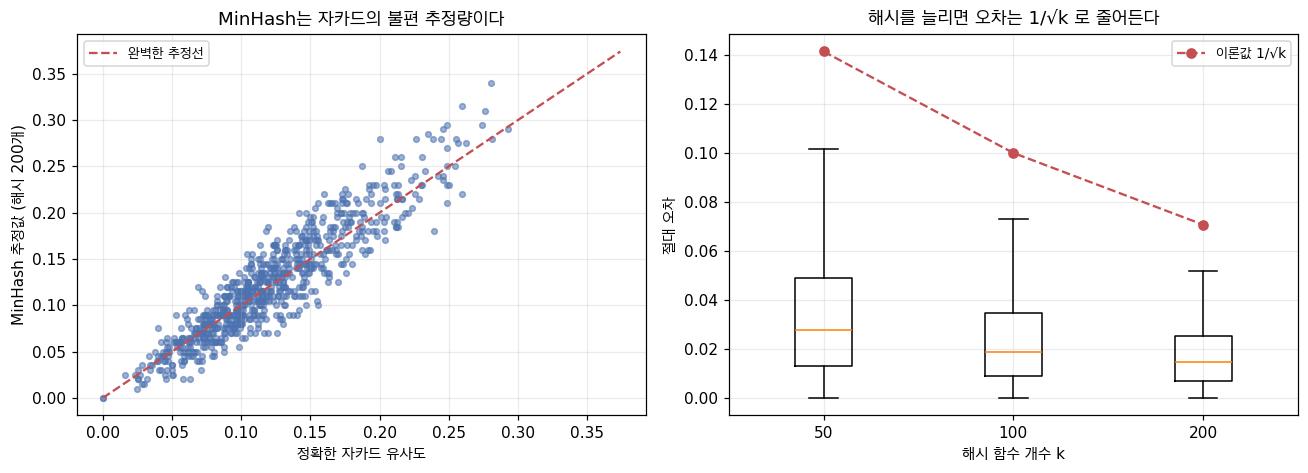

💡 이게 대규모 중복 문서 탐지의 원리다 — 모든 쌍을 비교하지 않고 시그니처만 비교한다.


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

sigs200 = [minhash_signature(s, 200, seed=42) for s in sets[:40]]
approx200 = np.array([minhash_jaccard(sigs200[i], sigs200[j]) for i, j in pairs])
ax1.scatter(exact, approx200, s=14, alpha=0.55, color="#4c72b0")
lims = [0, max(exact.max(), approx200.max()) * 1.1]
ax1.plot(lims, lims, ls="--", color="#c44e52", lw=1.5, label="완벽한 추정선")
ax1.set_xlabel("정확한 자카드 유사도"); ax1.set_ylabel("MinHash 추정값 (해시 200개)")
ax1.set_title("MinHash는 자카드의 불편 추정량이다")
ax1.legend(fontsize=9); ax1.grid(alpha=0.25)

ks = sorted(errors)
ax2.boxplot([errors[k] for k in ks], labels=[str(k) for k in ks], showfliers=False)
ax2.plot(range(1, len(ks) + 1), [1 / math.sqrt(k) for k in ks], "o--",
         color="#c44e52", label="이론값 1/√k")
ax2.set_xlabel("해시 함수 개수 k"); ax2.set_ylabel("절대 오차")
ax2.set_title("해시를 늘리면 오차는 1/√k 로 줄어든다")
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()
print("💡 이게 대규모 중복 문서 탐지의 원리다 — 모든 쌍을 비교하지 않고 시그니처만 비교한다.")

## 1️⃣4️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 사람들이 말하는 것 | 실제 의미 |
| --- | --- | --- |
| **노름(Norm)** | "벡터의 크기" | 벡터를 음이 아닌 스칼라로 보내면서 삼각 부등식·절대 동차성·(0일 때만 0)을 만족하는 함수 |
| **L1 노름** | "맨해튼 거리" | 성분 절댓값의 합. 최적화에서 희소성을 만들고 이상치에 강건하다 |
| **L2 노름** | "유클리드 거리" | 성분 제곱합의 제곱근. 우리가 아는 직선 거리 |
| **Lp 노름** | "일반화된 노름" | 성분 절댓값의 p제곱 합의 p제곱근. L1·L2는 특수한 경우 |
| **L∞ 노름** | "max 노름", "체비셰프 거리" | 성분 절댓값의 최댓값. `p → ∞` 일 때의 극한 |
| **코사인 유사도** | "벡터 사이의 각도" | 내적을 두 크기로 나눈 값. −1~+1. **길이를 무시한다** |
| **코사인 거리** | "1 − 코사인 유사도" | 유사도를 거리로 바꾼 것. 0~2 |
| **내적(Dot product)** | "정규화 안 한 코사인" | 성분별 곱의 합. 코사인 × 두 벡터의 크기 |
| **마할라노비스 거리** | "상관을 아는 거리" | 공분산 행렬로 화이트닝(상관 제거+정규화)한 공간에서의 L2 거리 |
| **자카드 유사도** | "집합의 겹침" | 교집합 크기 ÷ 합집합 크기. 벡터가 아닌 **집합**용 |
| **편집 거리** | "레벤슈타인 거리" | 한 문자열을 다른 문자열로 바꾸는 최소 삽입·삭제·치환 횟수 |
| **KL 발산** | "분포 사이의 거리" | 진짜 거리가 아니다(비대칭). Q로 P를 인코딩할 때 낭비되는 비트 |
| **Wasserstein 거리** | "earth mover's distance" | 한 분포를 다른 분포로 옮기는 최소 수송 비용. **진짜 거리다** |
| **근사 최근접 이웃(ANN)** | "ANN 검색" | HNSW·LSH·IVF 등. 정확 탐색보다 훨씬 빠르게 '거의 가장 가까운' 점을 찾는다 |
| **HNSW** | "벡터 DB 알고리즘" | 계층적 내비게이션 스몰월드 그래프. 다층 그래프 기반 ANN |
| **L1 정규화** | "Lasso" | 손실에 `‖w‖₁`을 더한다. 가중치를 정확히 0으로 만든다(희소성) |
| **L2 정규화** | "Ridge", "weight decay" | 손실에 `‖w‖₂²`을 더한다. 0에 가깝게 줄이지만 0으로 만들진 않는다 |
| **Elastic Net** | "L1 + L2" | 둘을 결합. 상관된 특징 그룹을 함께 다룬다 |

---

## 🎯 한 문장 정리

> **거리 함수는 "무엇을 무시할 것인가"에 대한 선언이다.**
> 그리고 그 선택이 최근접 이웃, 손실 함수, 정규화의 성격을 **전부** 결정한다.

| 과제 | 최적 거리 | 이유 |
| --- | --- | --- |
| 텍스트 유사도 | 코사인 | 크기는 잡음, 방향이 의미 |
| 이미지 픽셀 비교 | L2 | 공간 관계가 중요하고 특징 스케일이 비슷함 |
| 희소 고차원 특징 | L1 | 강건하고, 드문 큰 차이를 증폭하지 않음 |
| 집합 겹침(태그) | 자카드 | 데이터가 본래 집합형 |
| 문자열 매칭 | 편집 거리 | 연산이 사람의 편집 직관과 대응 |
| 이상치 탐지 | 마할라노비스 | 특징 상관과 스케일을 반영 |
| 분포 비교 | KL 발산 | Q로 P를 대체할 때 잃는 정보량 |
| GAN 학습 | Wasserstein | 겹치지 않아도 기울기를 준다 |
| 임베딩(벡터 DB) | 코사인 / 내적 | 임베딩은 의미를 방향에 담도록 학습됨 |
| 추천 | 내적 | 크기가 인기·신뢰도를 인코딩할 수 있음 |
| DNA 서열 | 가중 편집 거리 | 치환 비용이 염기쌍마다 다름 |
| 제조 품질관리 | L∞ | 단 하나의 축에서라도 최악 편차가 중요 |

---

## 📖 더 읽을거리 (Further Reading)

- [FAISS: A Library for Efficient Similarity Search](https://github.com/facebookresearch/faiss) — 수십억 규모 ANN 검색을 위한 Meta 라이브러리
- [Wasserstein GAN (Arjovsky et al., 2017)](https://arxiv.org/abs/1701.07875) — Earth Mover's distance를 GAN에 도입한 논문
- [Locality-Sensitive Hashing (Indyk & Motwani, 1998)](https://dl.acm.org/doi/10.1145/276698.276876) — ANN의 기초 알고리즘
- [Efficient Estimation of Word Representations (Mikolov et al., 2013)](https://arxiv.org/abs/1301.3781) — Word2Vec. 임베딩에서 코사인이 기본이 된 출발점
- [sklearn.neighbors 문서](https://scikit-learn.org/stable/modules/neighbors.html) — 거리 척도와 이웃 알고리즘 실전 가이드